# qPCR analysis

The purpose of this code is to automate qPCR analysis from the ViiA7 machine after a comparative Ct run using TaqMan reagents. For this analysis, both the reference gene (= housekeeping gene) and the target gene must be amplified in the same well. It is also required to set meaningful sample names in the machine, which allows the Python script to plot gene expression per condition (sample name).

This workflow is an adaptation of the LinRegPCR method (Untergasser et al., $2021)^{1}$ suitable for data obtained from the ViiA7 machine. Every modification from the initial method is mentioned in this document.

First of all, as the machine already provides baseline correction and Ct identification, these steps are not recalculated using the LinRegPCR method.

Here are the steps of calculation performed by the code:

- ### Calculating reaction efficiency and removing outliers:

First of all, the exponential phase of the amplification curve is identified based on the last point of the exponential phase, characterized by the second derivative maximum SDM $^{1}$. From that point, the four previous points are traced back to ensure at least three consecutive cycles in the exponential phase to calculate the PCR efficiency $^{1}$.

The fluorescence values of the exponential phase (the four points mentioned above) of the baseline-corrected amplification curve are log2-transformed in order to perform a linear regression. The slope × 100 corresponds to the reaction efficiency in percentage.

The user can set minimum and maximum efficiency thresholds to remove reactions for which the efficiency is not considered sufficient. Untergasser et al (2020)$^{1}$ use the Grubbs test to remove outlier reaction efficiencies, which is a technique used to remove only one outlier at a time and may not be optimal when several outliers are present.

- ### Calculating the efficiency-corrected target quantity $N_0$

First of all, an average PCR reaction efficiency per assay (= per GOI, not per well) is calculated in order to obtain a less variable mean PCR efficiency per $assay^{1}$.

For each well, the efficiency-corrected target quantity $N_0$ is calculated with the following formula $^{1}$:

$N_0 = N_q E^{-Cq}$   with E being the average reaction efficiency for the GOI.

Note: The well-known ΔΔCt method, in which data are processed using Ct values, is avoided because it may introduce bias during data processing, particularly when averaging Ct values. Ct values correspond to the log₂ of the initial quantity, and therefore the mean of log₂-transformed data is not equivalent to the log₂ of the mean of the non-transformed data $^{2}$.

For each well, the expression of the GOI is normalized by the expression of the reference gene (housekeeping):

$N_0 = N_0(GOI) / N_0(housekeeping)$

Finally, these data are plotted in a bar plot according to the sample name (experimental condition), and an Excel file is generated containing the following information:
- the data from the initial results sheet
- reaction efficiency (in %)
- real efficiency (multiplication factor of the cDNA quantity between two successive cycles)
- efficiency-corrected target quantity $N_0$
- normalized quantity with the housekeeping gene
- an additionnal sheet with the outliers


The initial LinRegPCR method, developed by Untergasser et al. (2021), is licensed under a Creative Commons Attribution 4.0 International License, which permits use, sharing, adaptation, distribution, and reproduction in any medium or format. To view a copy of this licence, visit:

http://creativecommons.org/licenses/by/4.0/

## References 
1. Untergasser, A., Ruijter, J.M., Benes, V. et al. Web-based LinRegPCR: application for the visualization and analysis of (RT)-qPCR amplification and melting data. BMC Bioinformatics 22, 398 (2021). https://doi.org/10.1186/s12859-021-04306-1

2. Lixiang, F., Rongqian, Z., Zhang, K., & Yang, W. (2025). Comparison of the 2 -C T method and the 2 -ΔΔC T method for real-time qPCR data analysis. openRxiv. https://doi.org/10.1101/2025.07.16.665089





=============================================================================================================================================

1. Import data for the excel file generated by the machine (the file must be in .xlsx)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

#import data
data = pd.read_excel('FLS OA 10.xlsx', sheet_name=['Amplification Data','Results'])

#GOI
genes_input = input("Enter gene names separated by commas: ")
genes_list = [g.strip() for g in genes_input.split(",")]

#Housekeeping gene
reference_input = input("Enter the only gene reference name: ")
reference_gene = reference_input.strip()

#Number of cycles
nb_cycl_input = input("Enter the number of cycle (it must be the same for all samples): ")
nb_cycl = int(nb_cycl_input)

#reaction efficiency threshold
minimum_efficiency_input = input("Enter your minimum threshold of reaction efficency in percent without writting the symbol % (suggestion: 85)")
efficience_min = int(minimum_efficiency_input)
maximum_efficiency_input = input("Enter your maximum threshold of reaction efficency in percent without writting the symbol % (suggestion: 115)")
efficience_max = int(maximum_efficiency_input)

# Distinguish between amplification and results data
amplification = data['Amplification Data']
results = data['Results']

2. Dataframe set up  

In [37]:
# set up the amplification dataframe by removing the non-relevant lines and columns, and renaming the columns
df_ampli = amplification.loc[amplification.iloc[:, 3].notna(), :]
df_ampli = df_ampli.iloc[1:,:] 
df_ampli = df_ampli.reset_index(drop = True)
df_ampli.columns = ['well', 'cycle', 'target name', 'Rn', 'Delta Rn']


3. Reaction efficiency calculation and identification of altered amplifications (outliers)

C:\Users\jeanj\AppData\Local\Temp\ipykernel_38476\3085265200.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
c:\Users\jeanj\AppData\Local\Schrodinger\PyMOL2\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


⚠️ Not enough correct points or non-finite values for=76, gene=NOX3
⚠️ Not enough correct points or non-finite values for=78, gene=NOX3
⚠️ Not enough correct points or non-finite values for=79, gene=NOX3
⚠️ Not enough correct points or non-finite values for=80, gene=NOX3


c:\Users\jeanj\AppData\Local\Schrodinger\PyMOL2\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


⚠️ Not enough correct points or non-finite values for=81, gene=NOX3
⚠️ Not enough correct points or non-finite values for=126, gene=C1QL2


,efficicence,coordinate
0,94.86,1PUM1
1,83.07,1SUN1
2,100.71,2PUM1
3,89.21,2SUN1
4,100.63,3PUM1
...,...,...
157,108.94,199EFNA4
158,90.20,200PUM1
159,108.70,200EFNA4
160,97.19,201PUM1


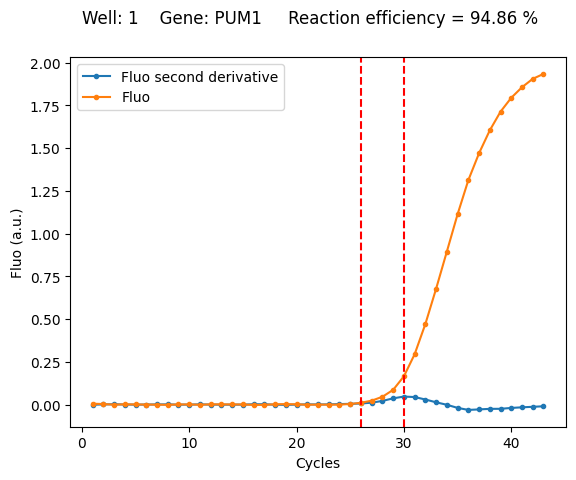

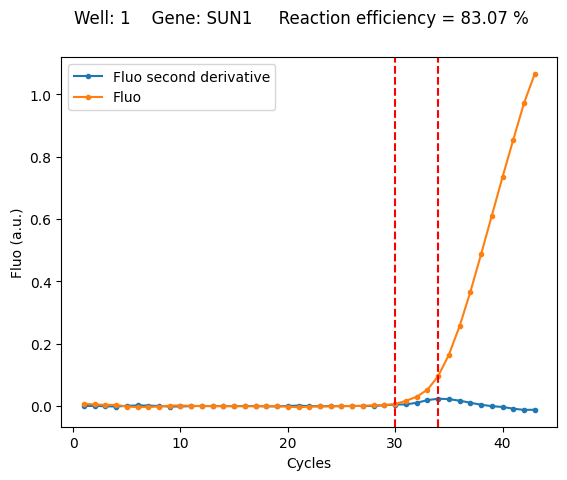

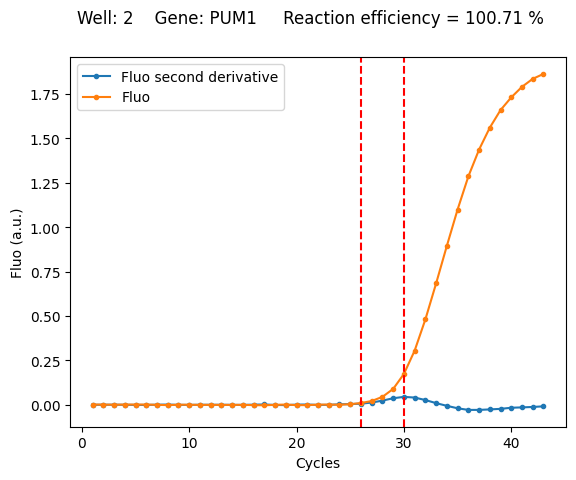

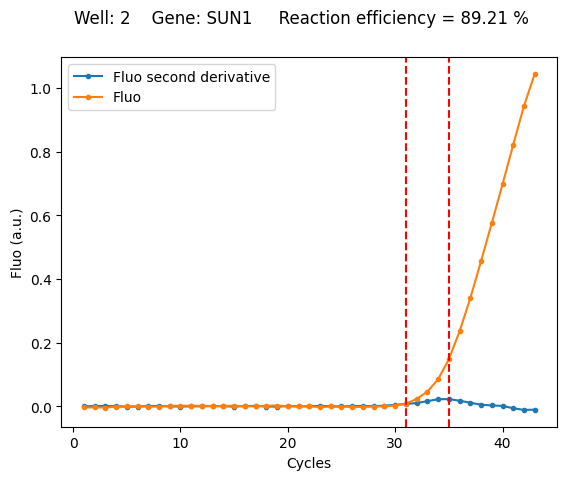

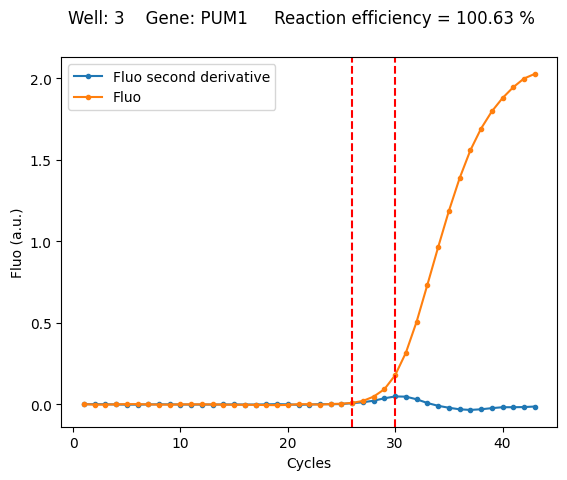

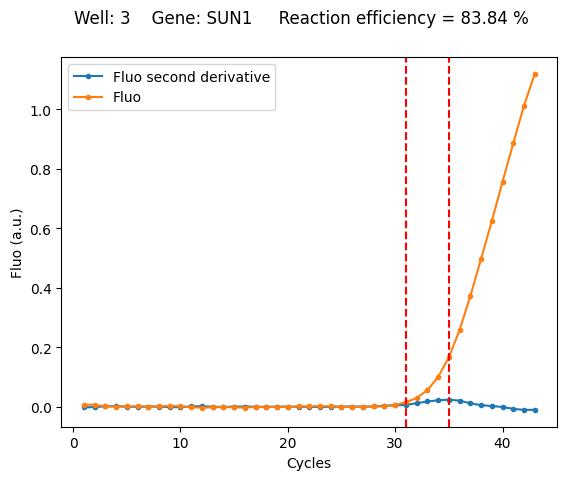

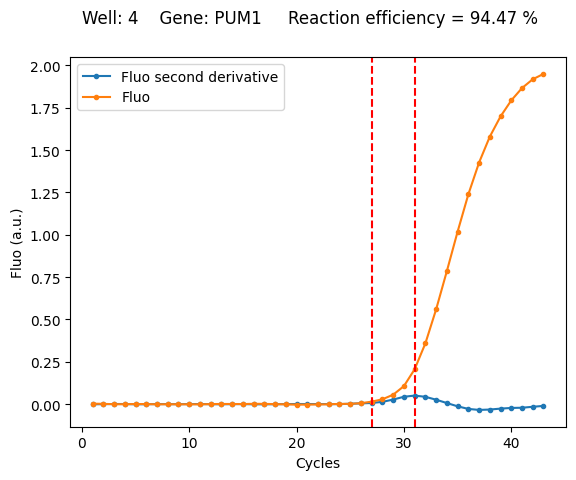

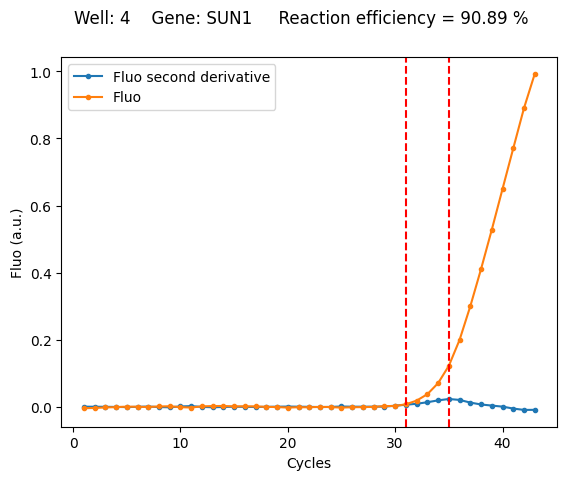

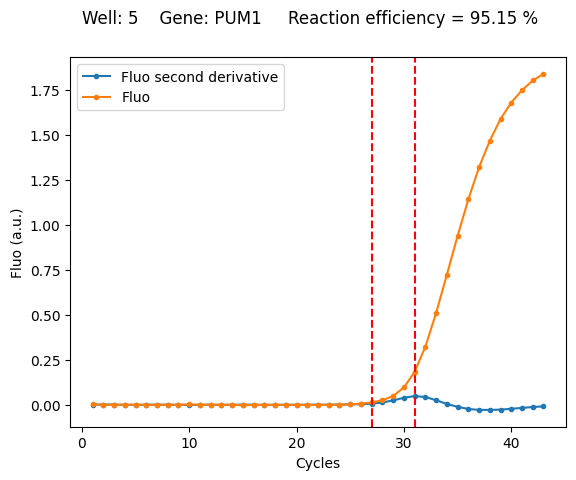

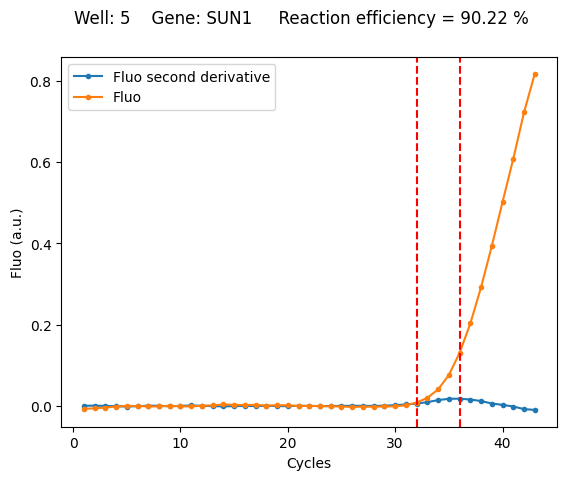

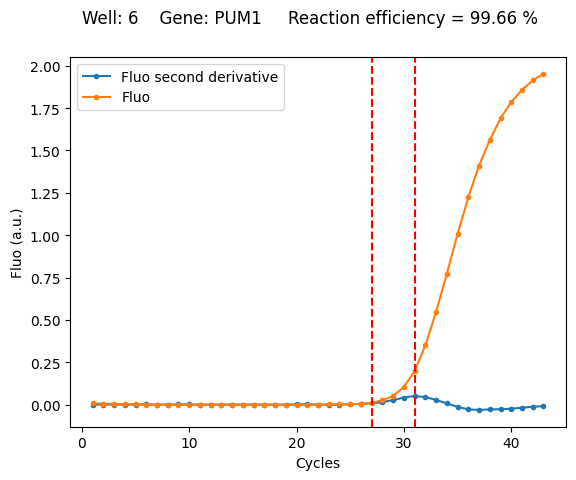

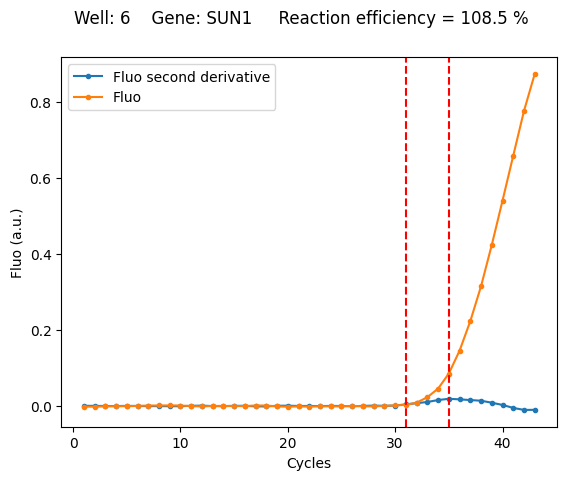

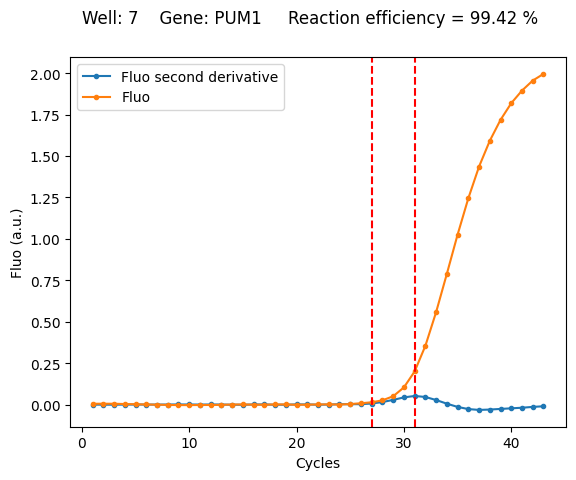

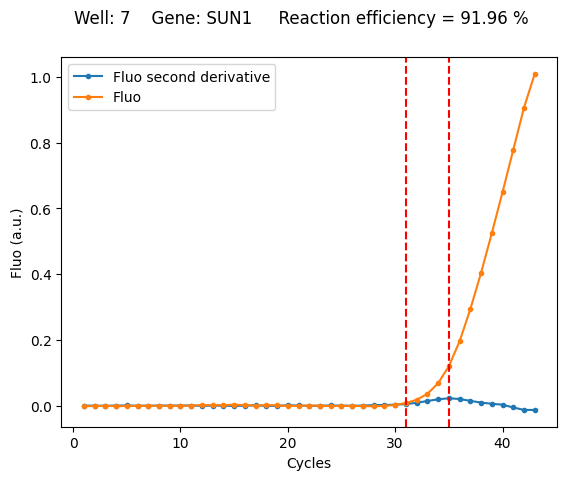

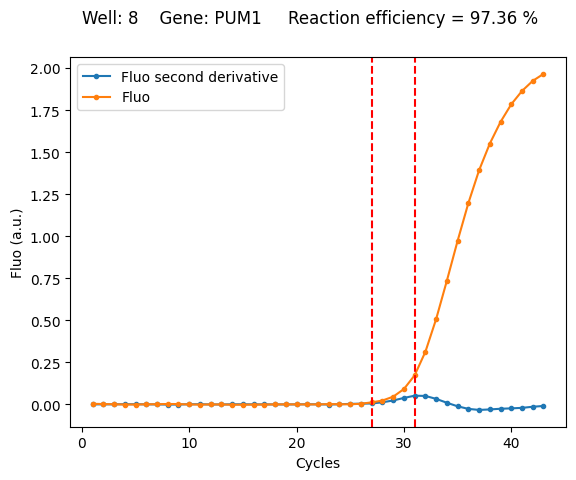

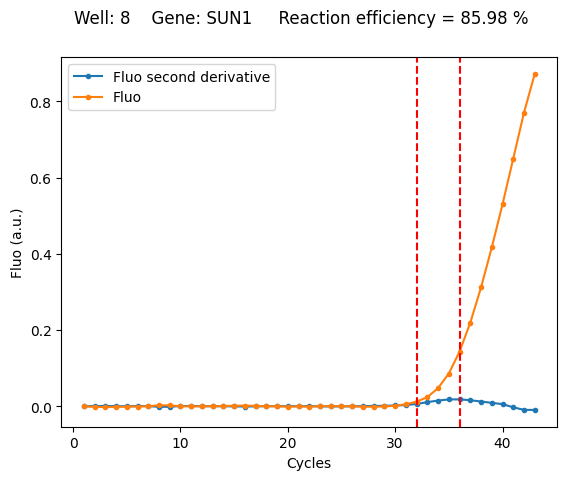

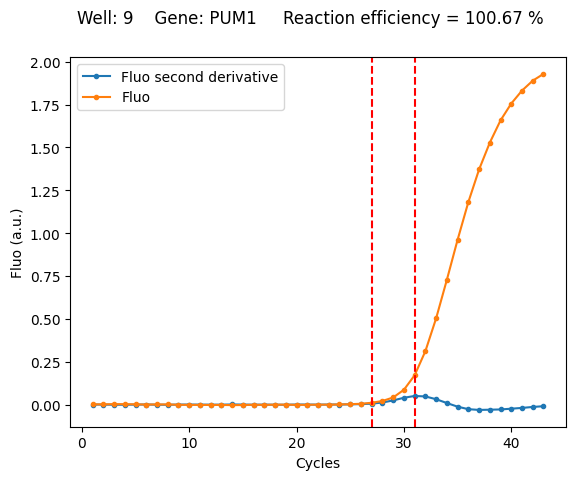

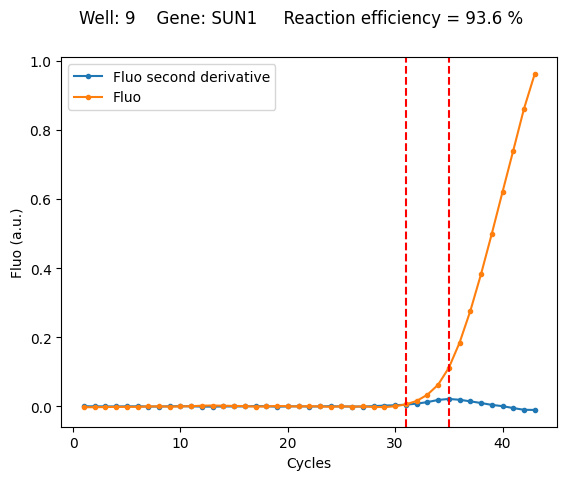

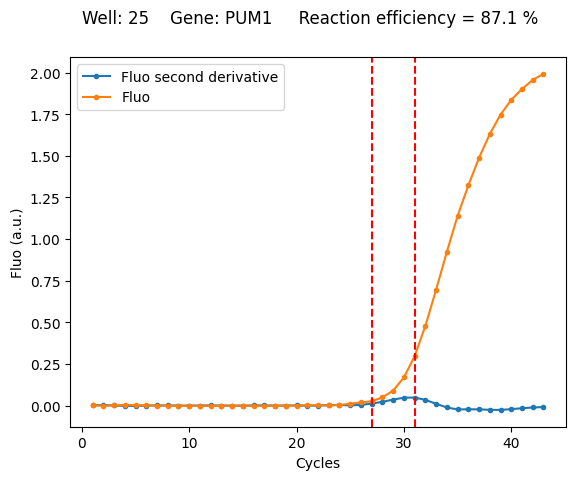

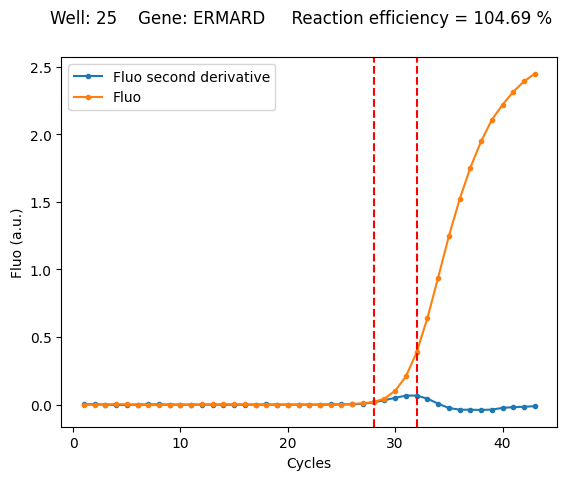

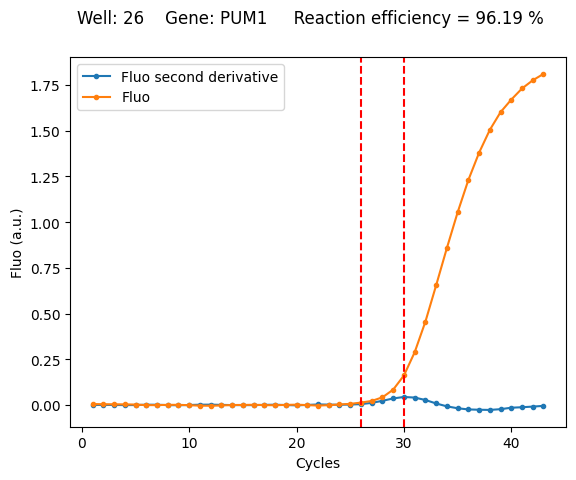

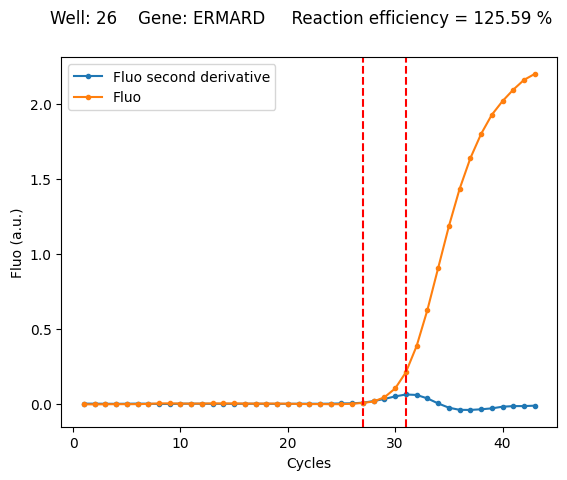

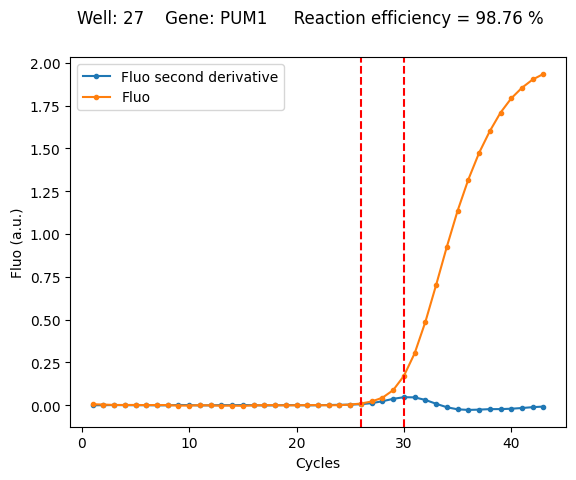

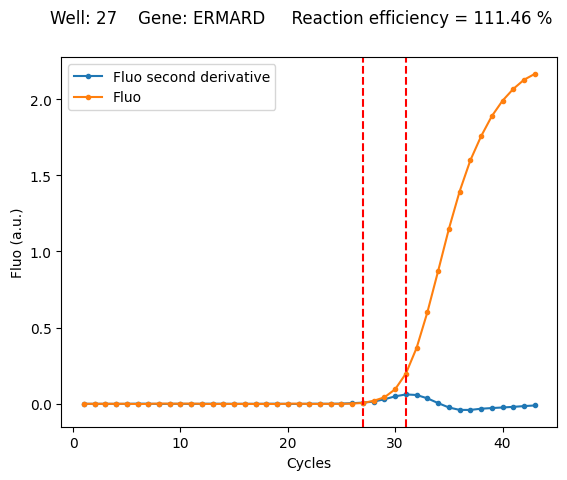

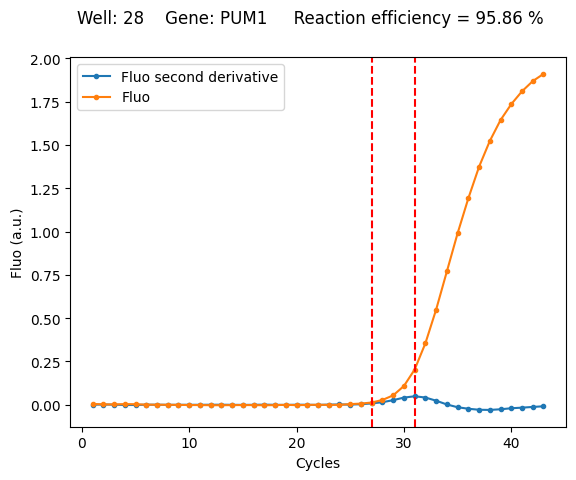

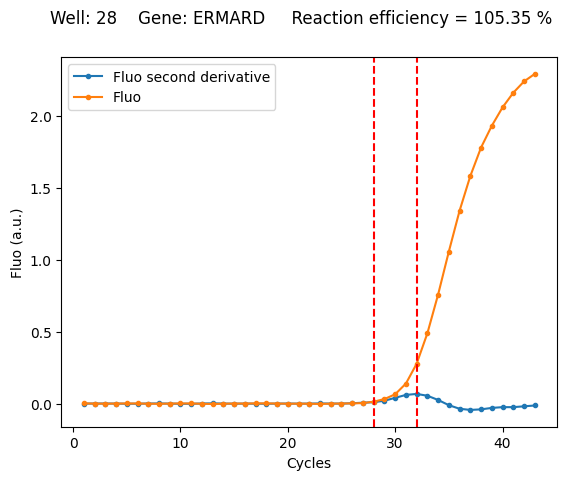

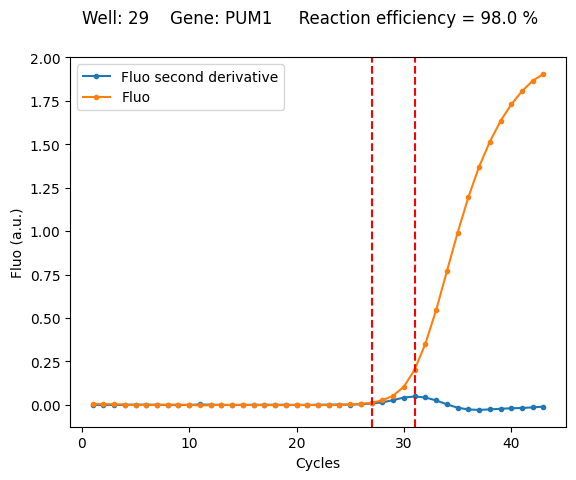

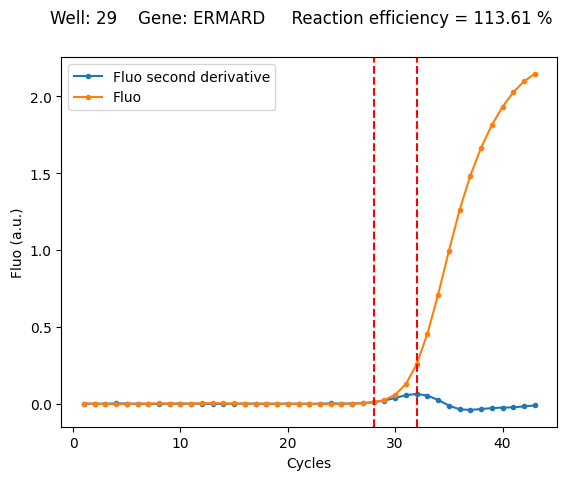

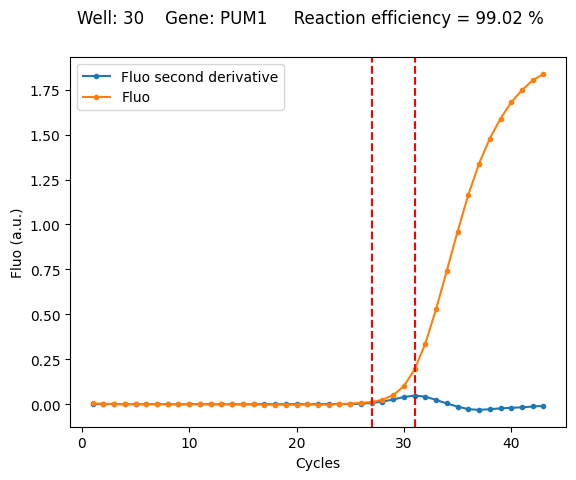

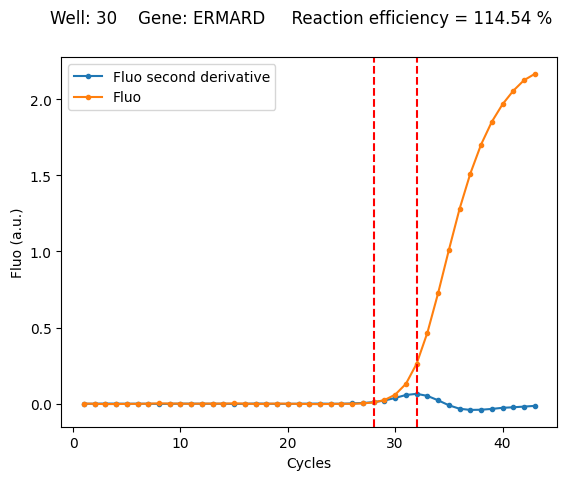

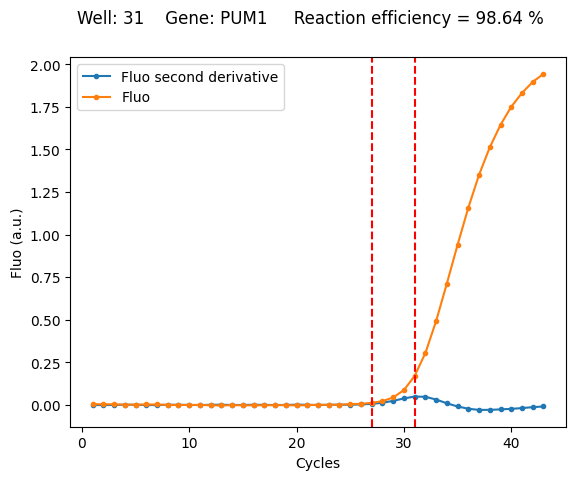

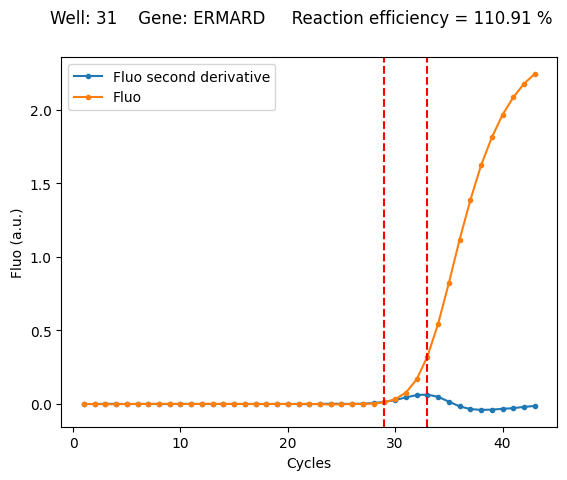

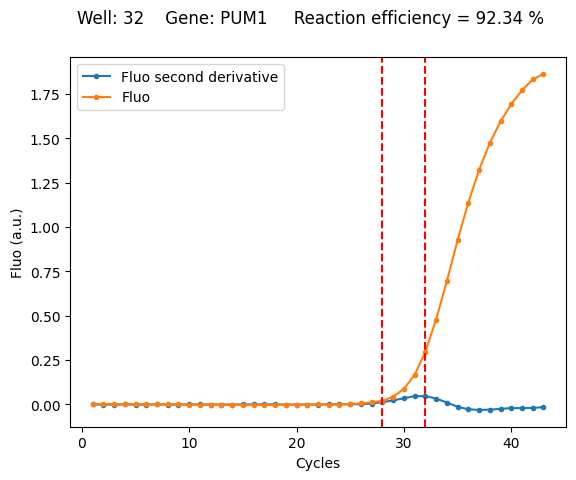

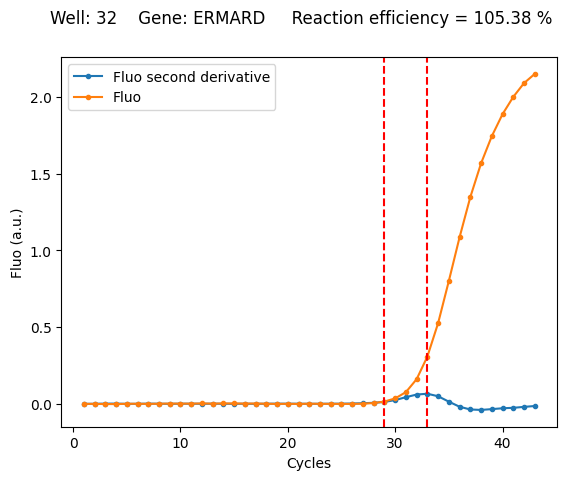

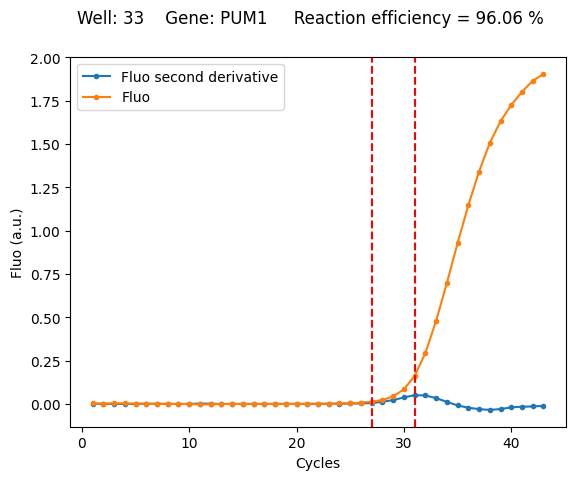

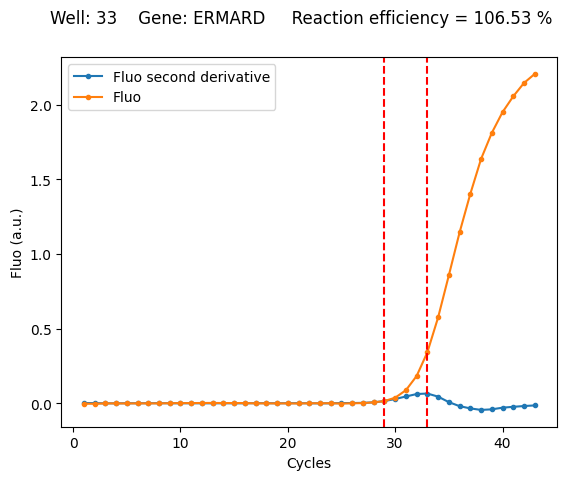

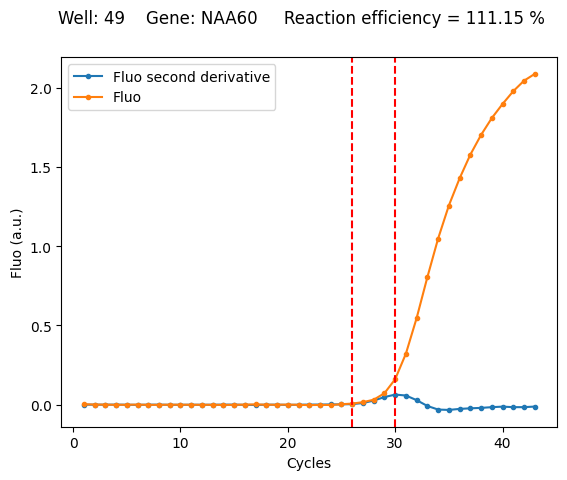

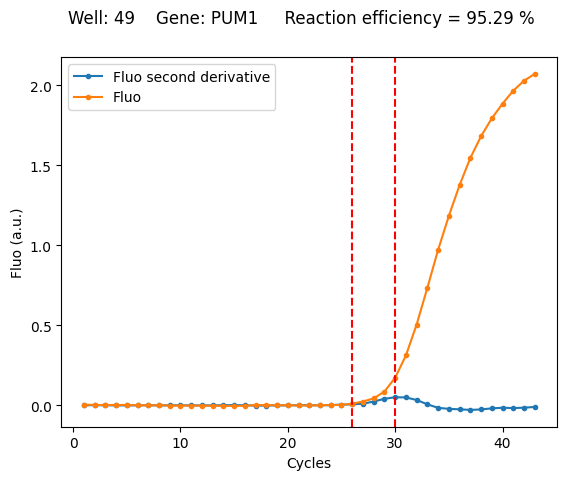

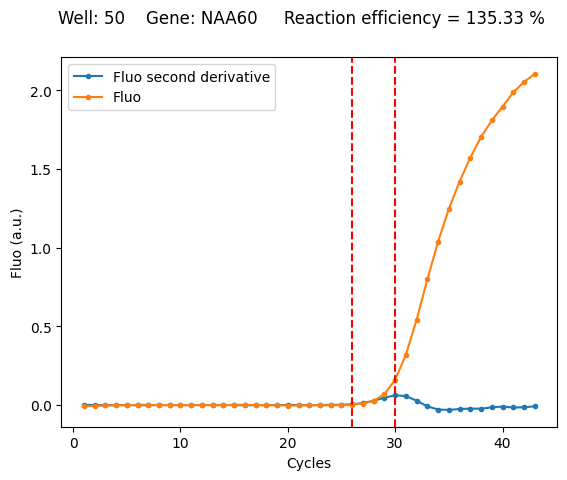

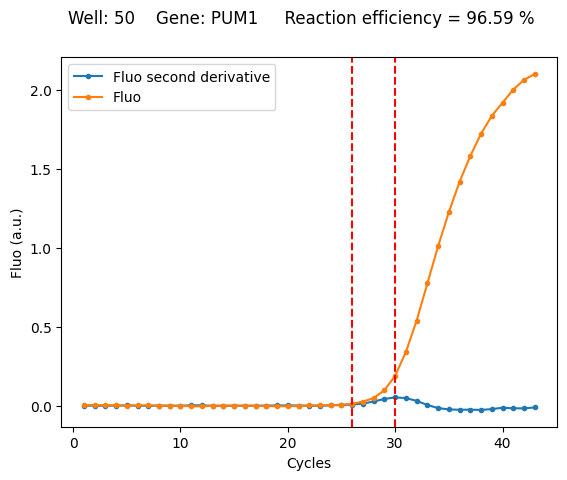

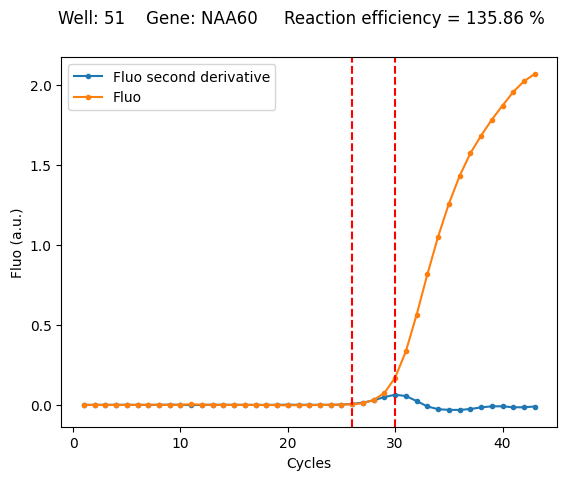

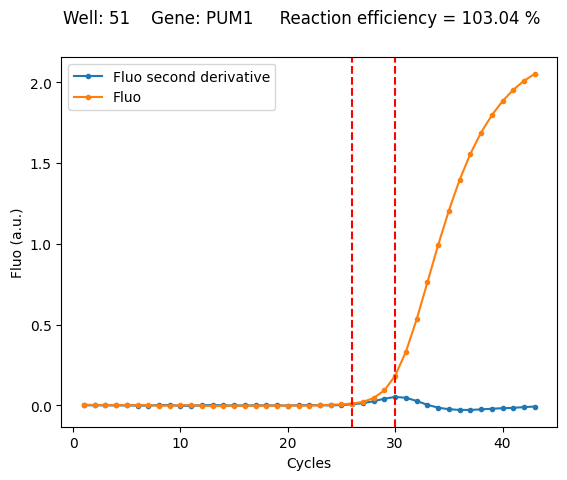

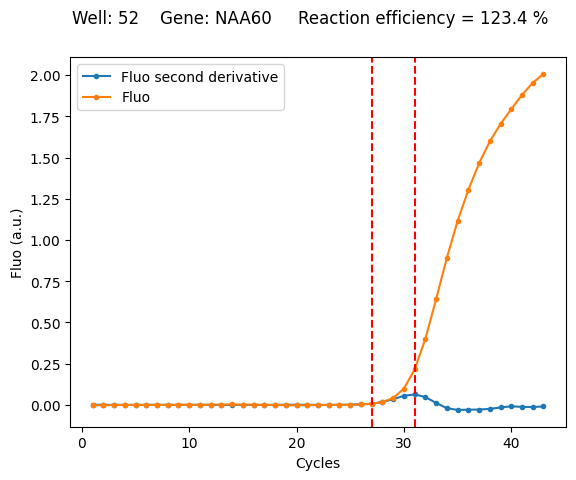

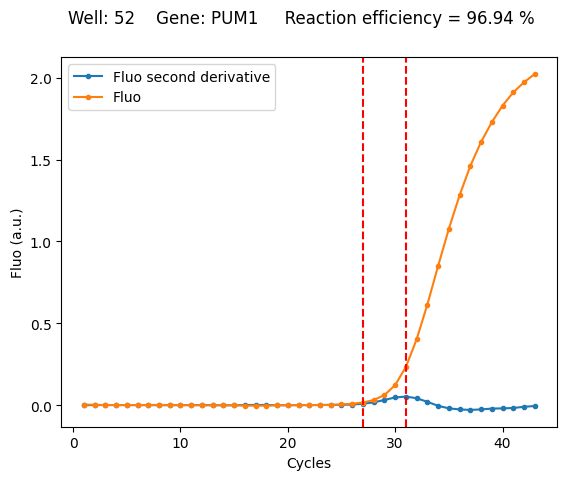

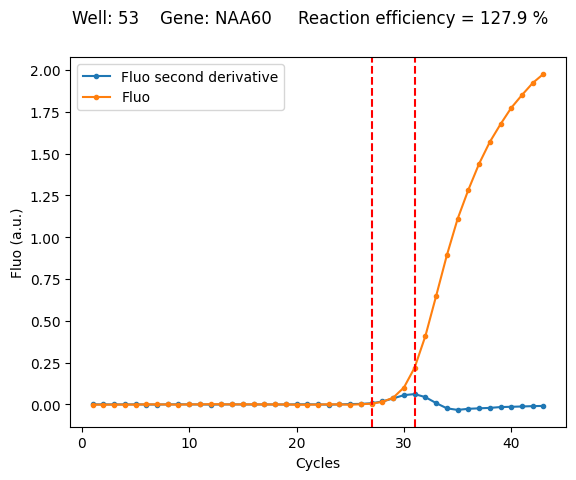

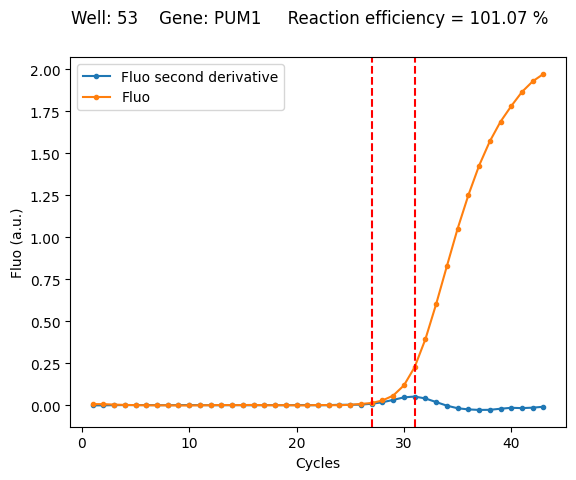

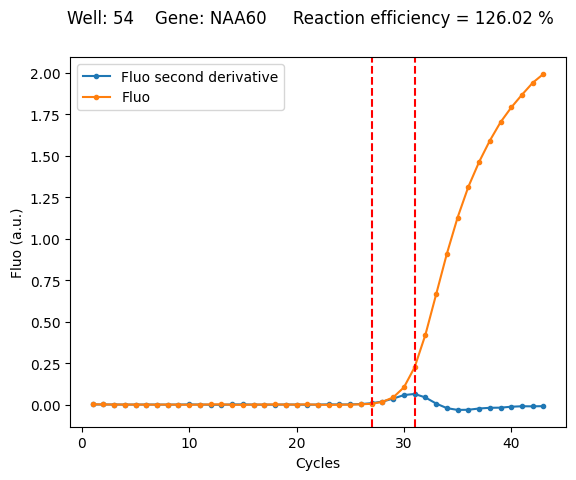

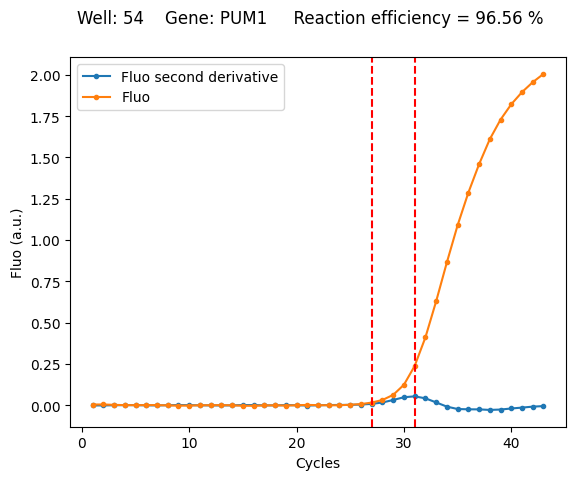

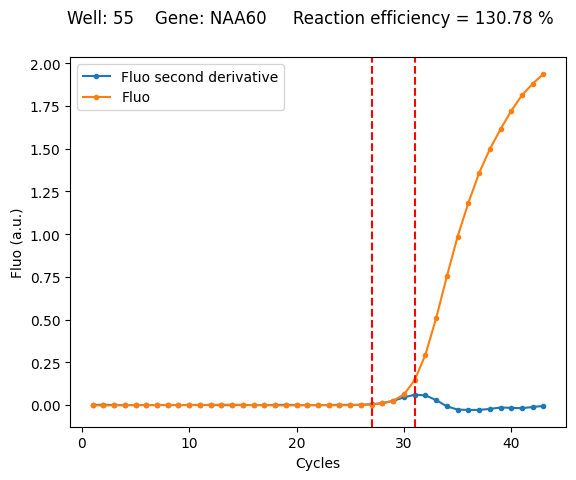

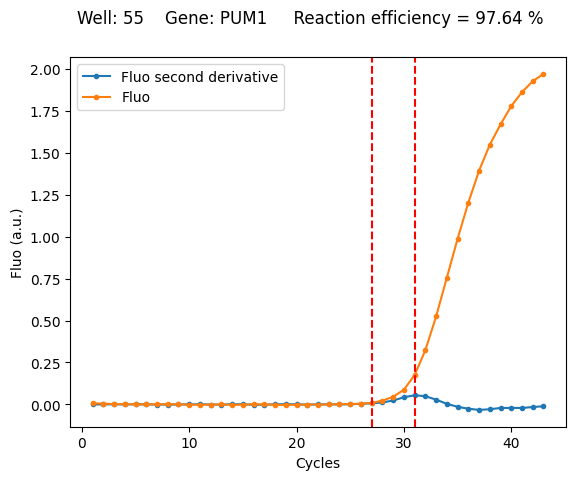

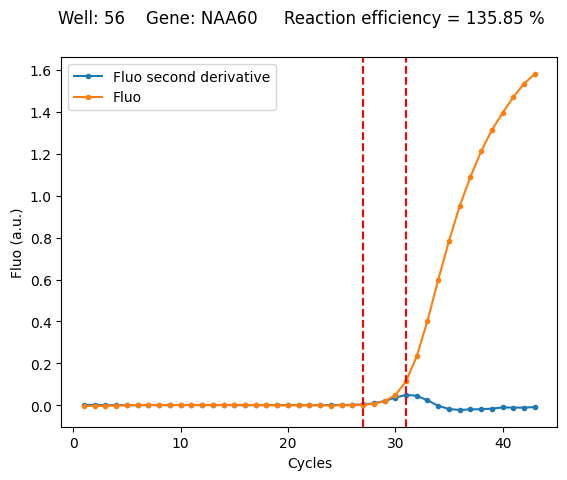

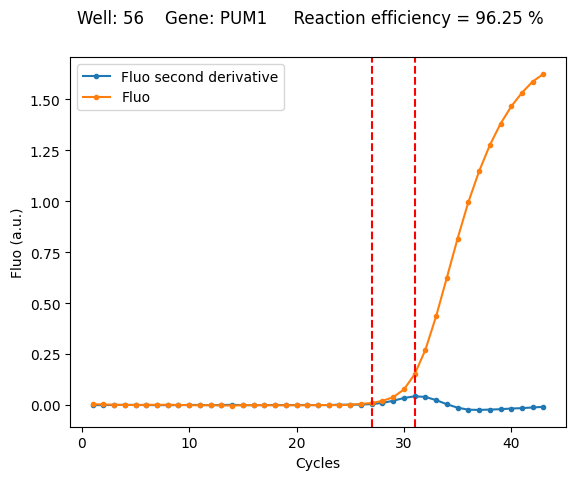

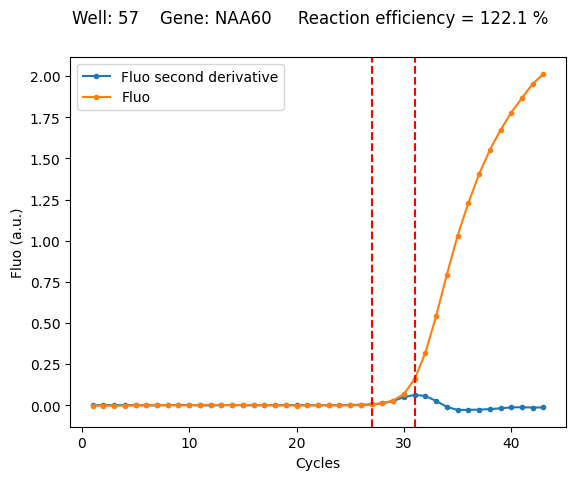

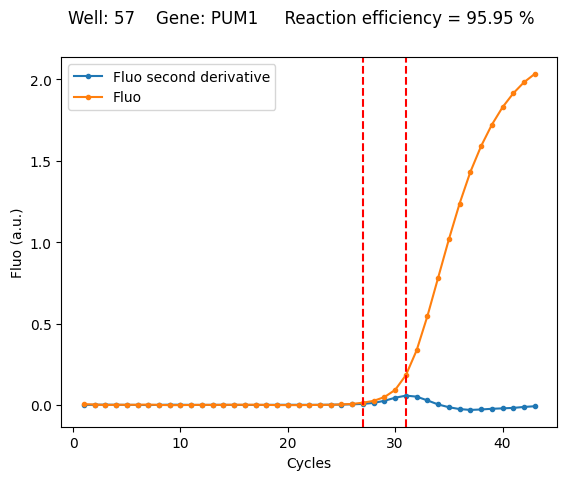

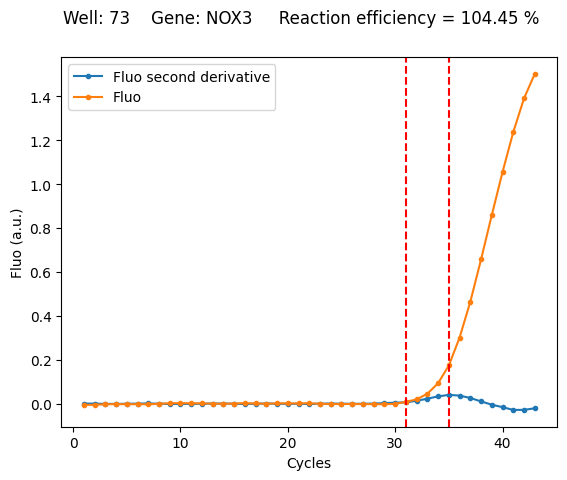

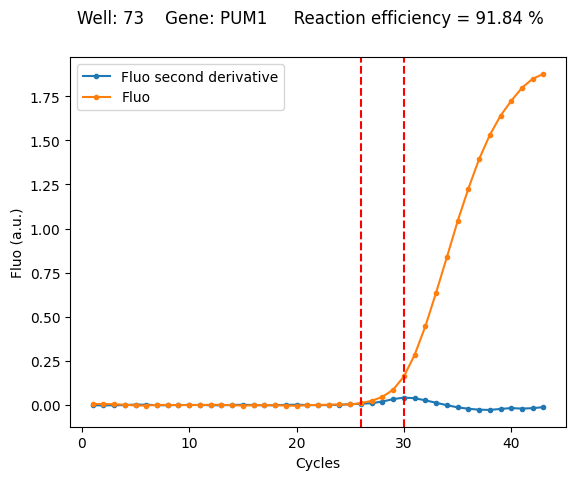

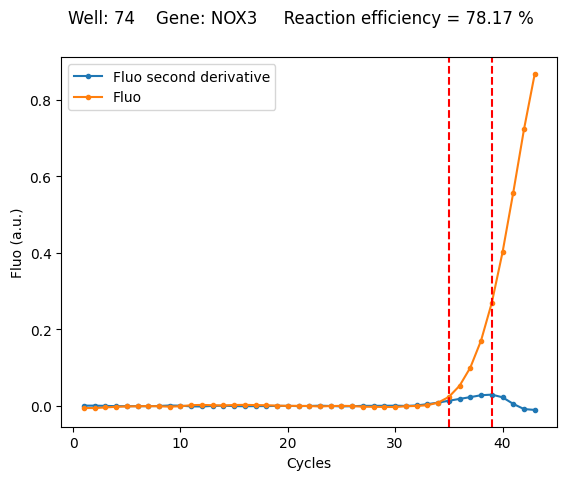

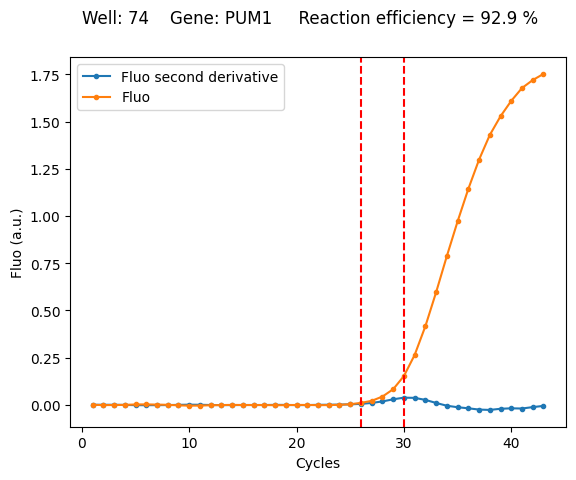

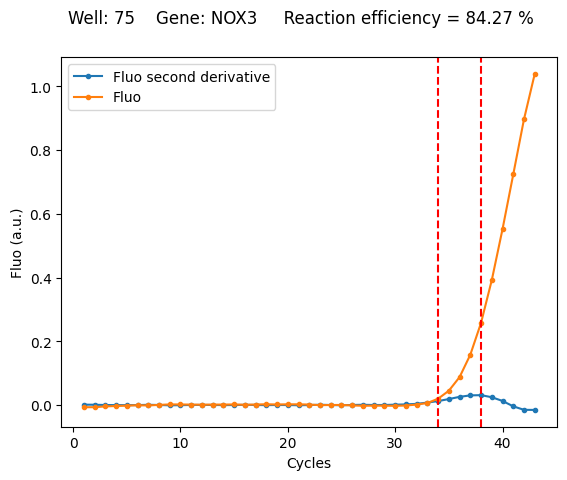

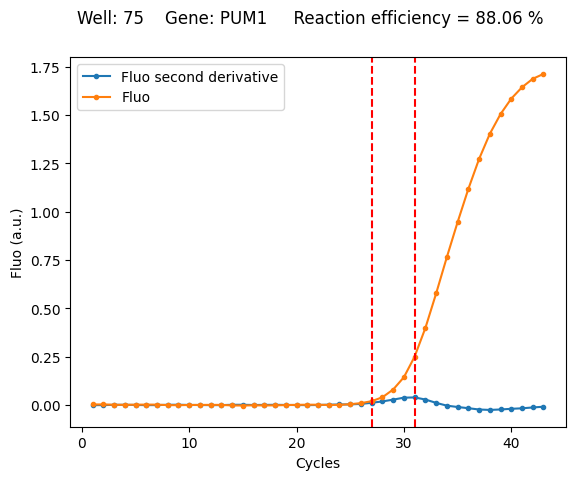

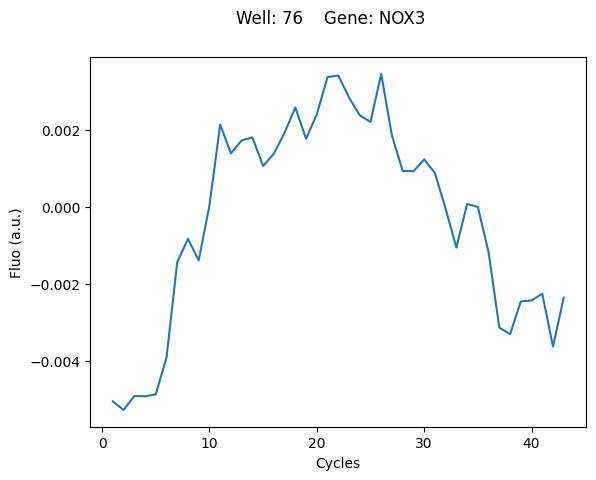

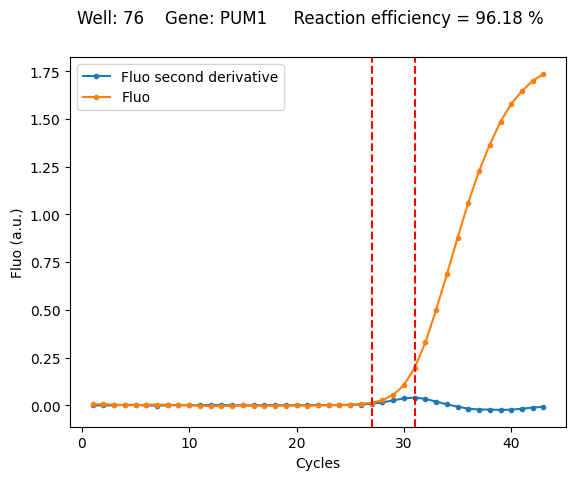

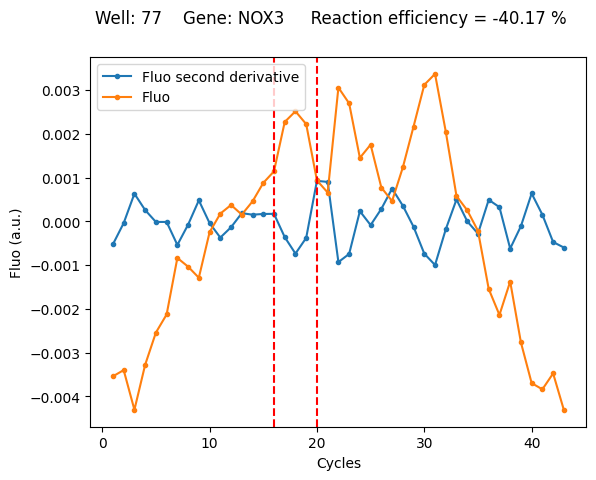

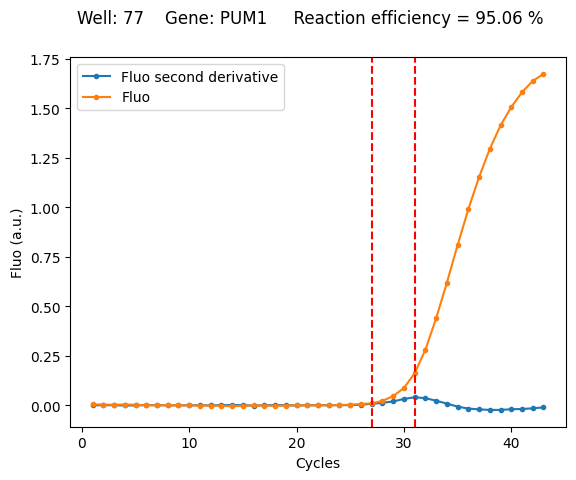

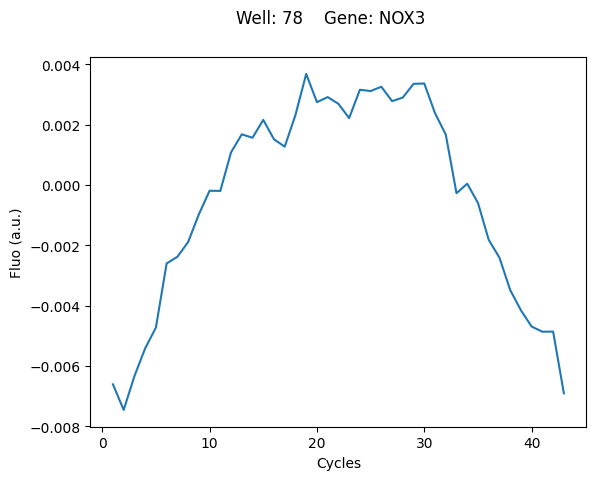

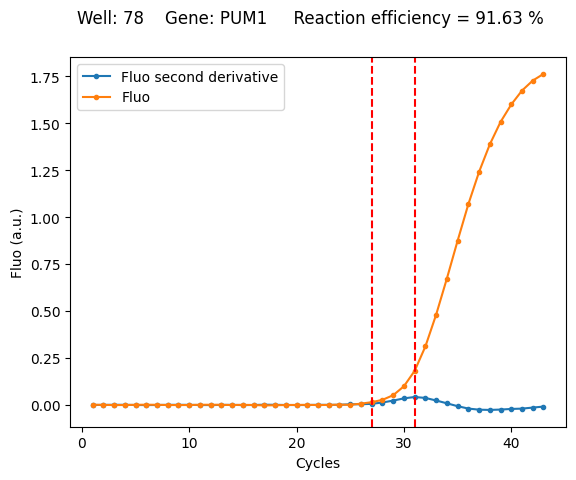

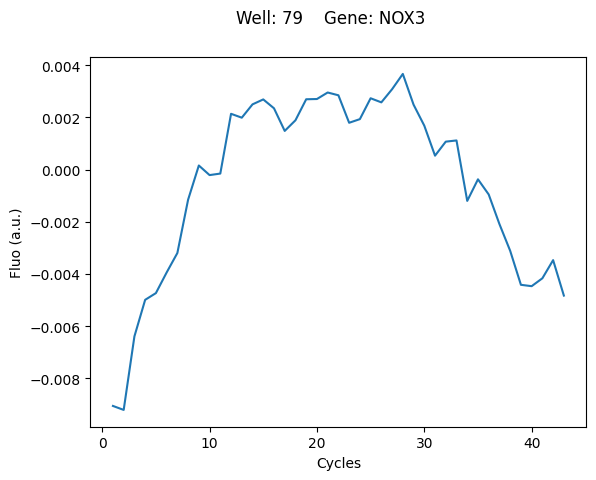

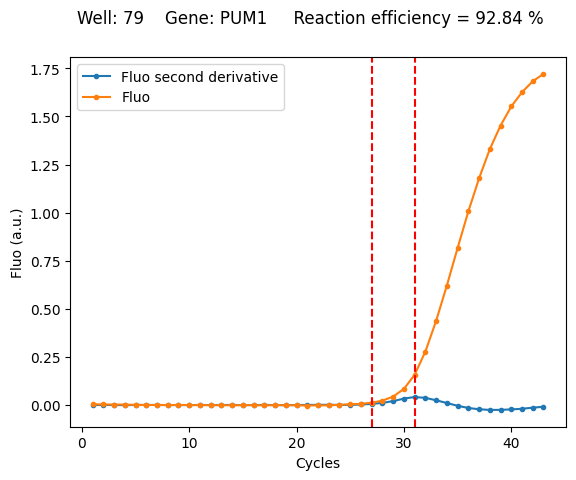

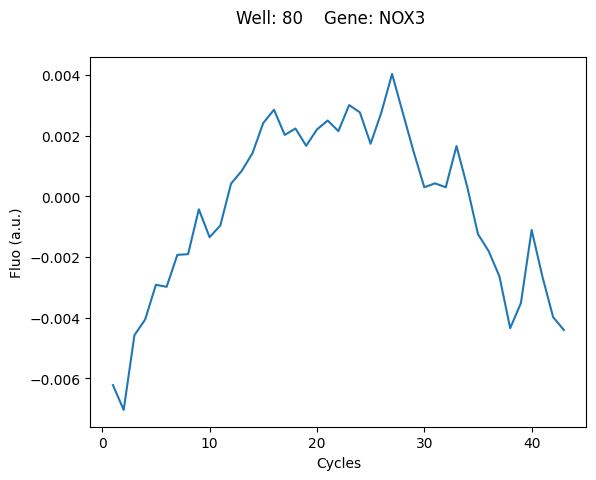

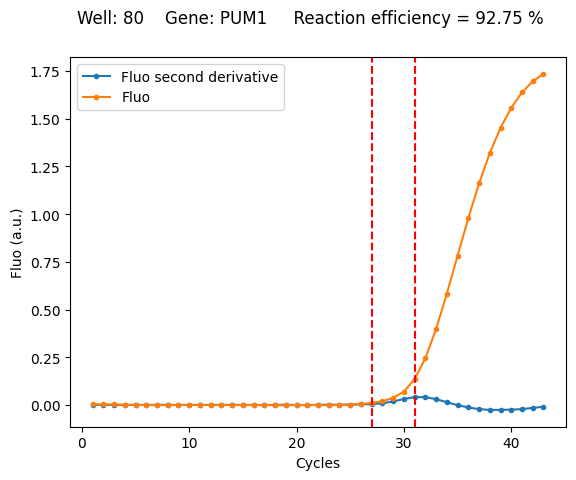

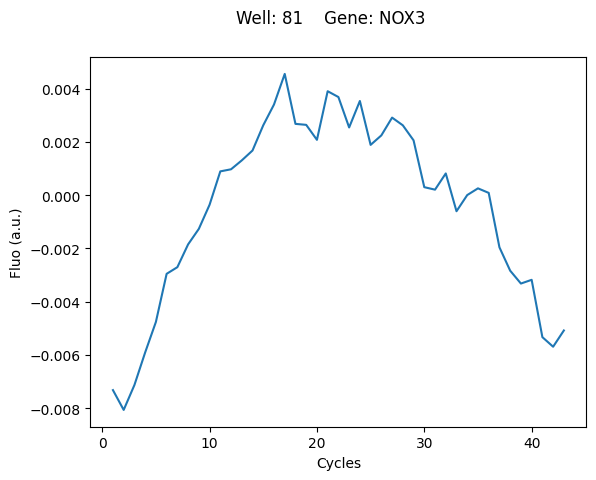

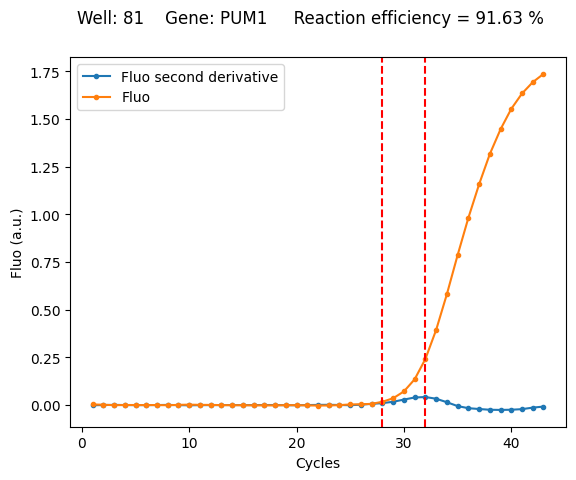

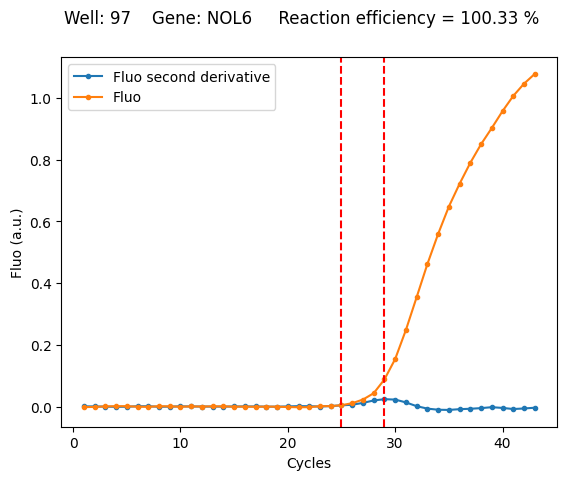

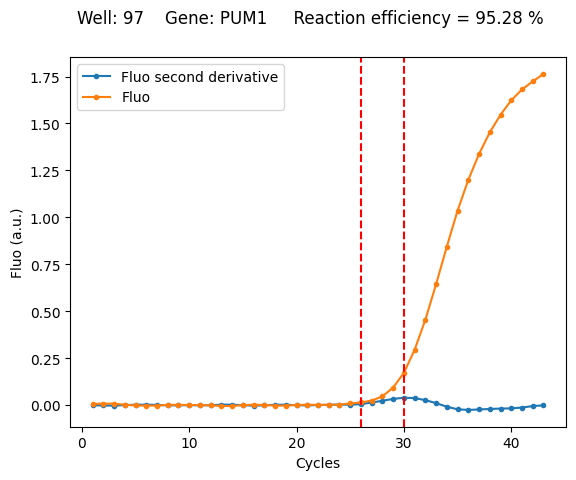

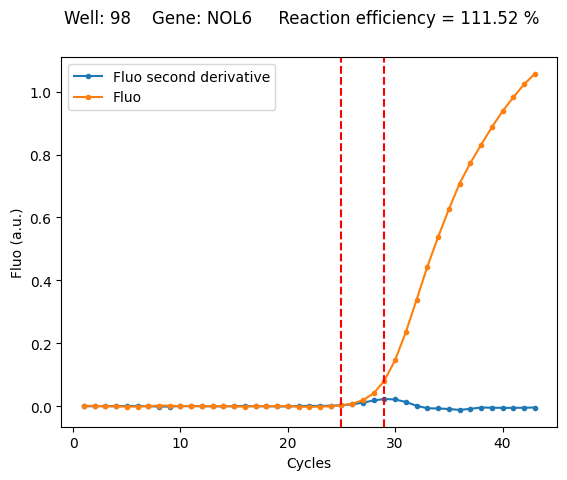

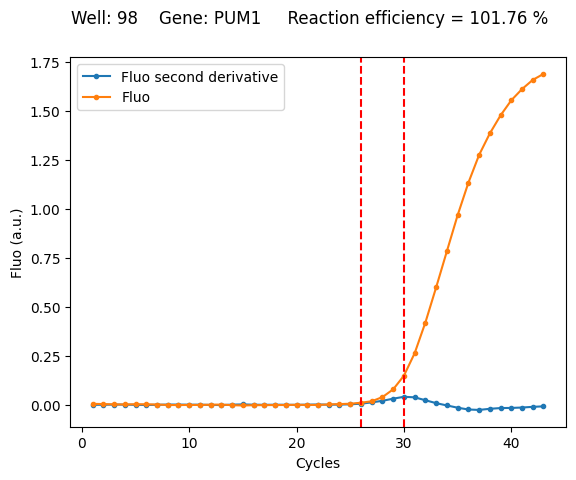

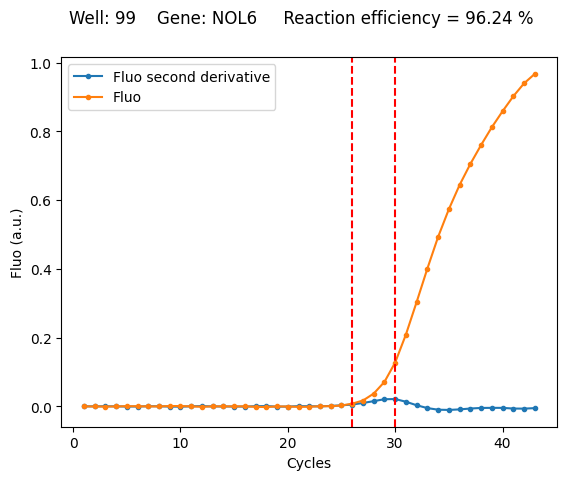

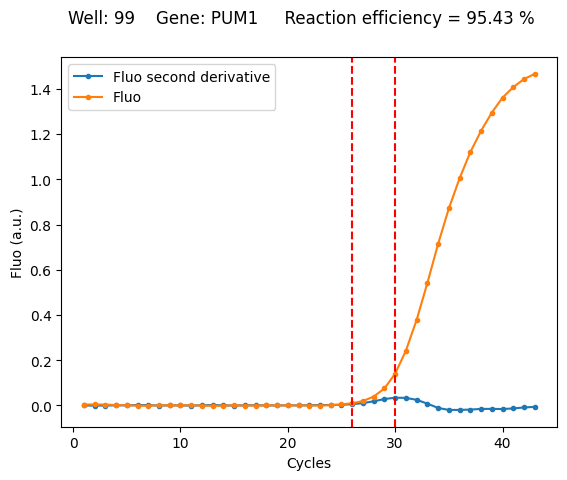

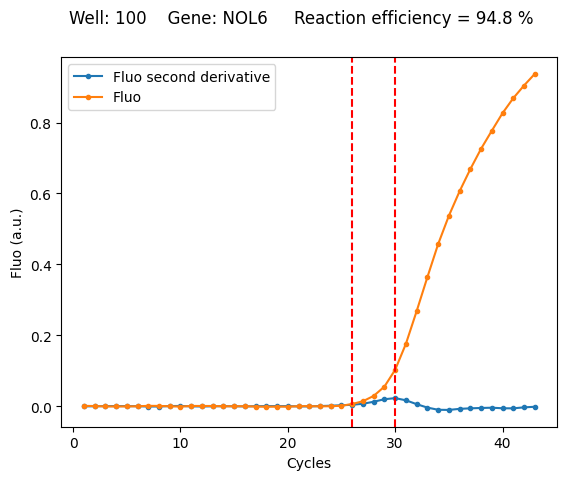

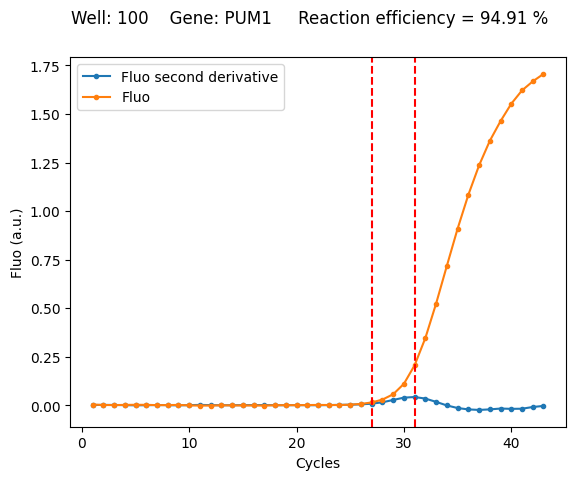

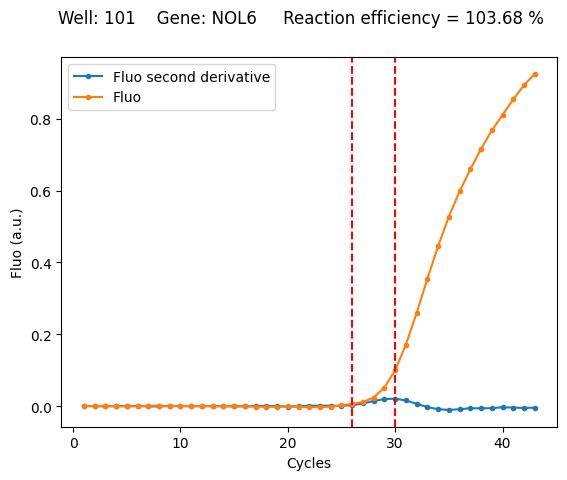

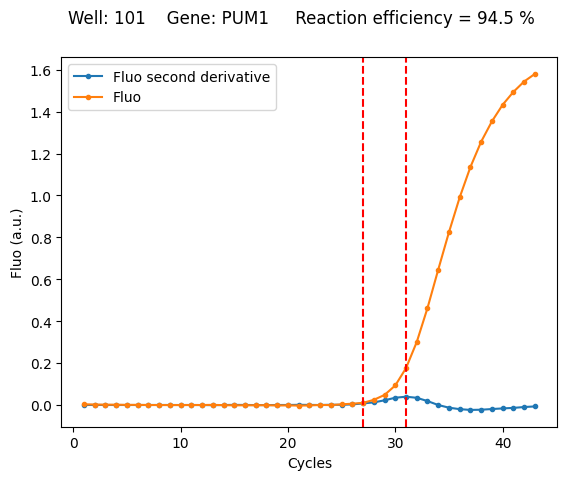

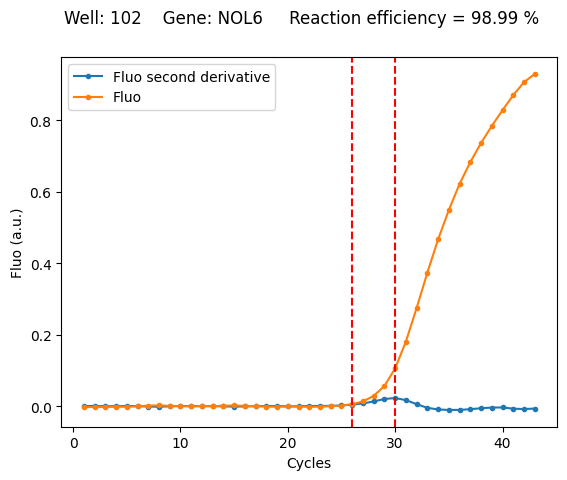

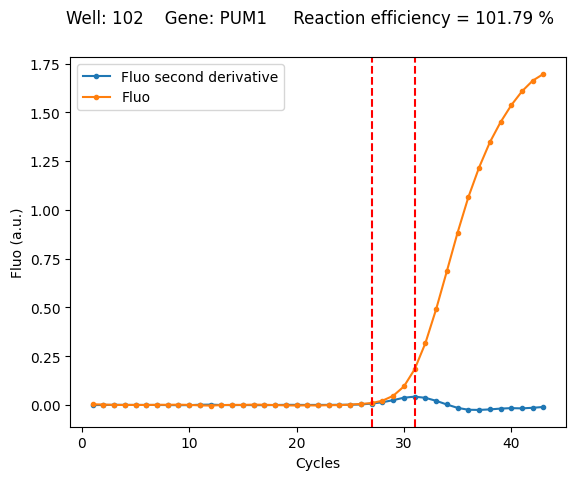

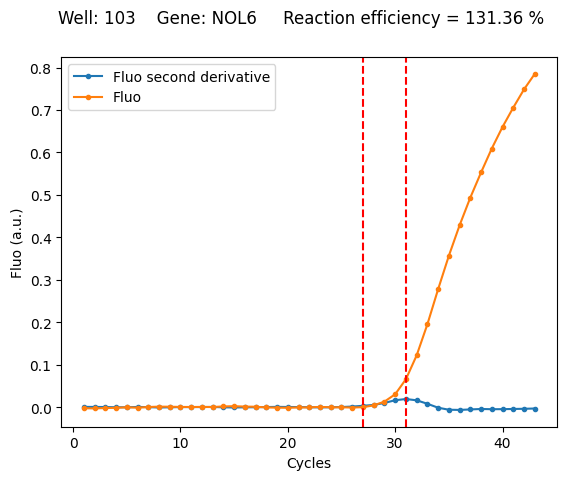

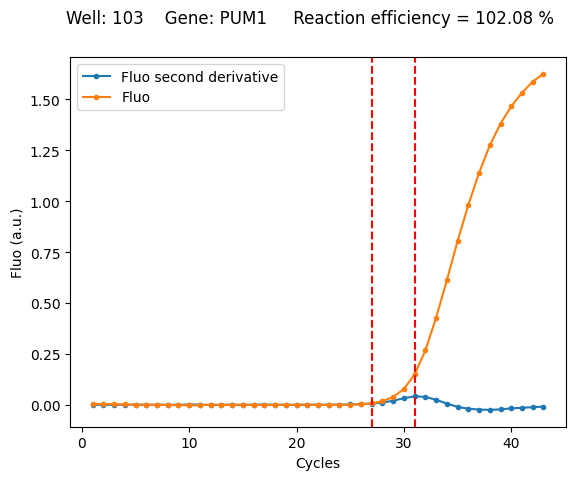

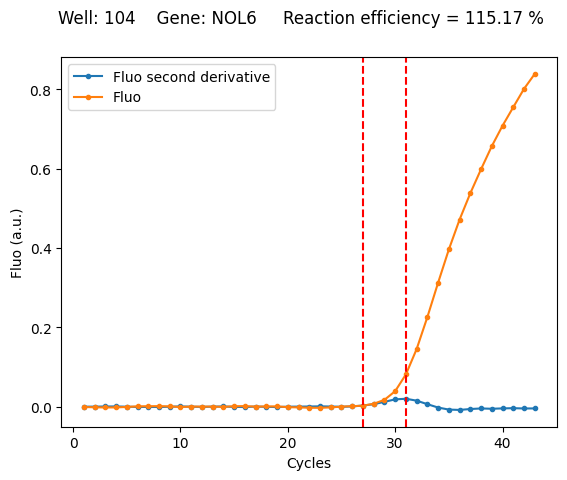

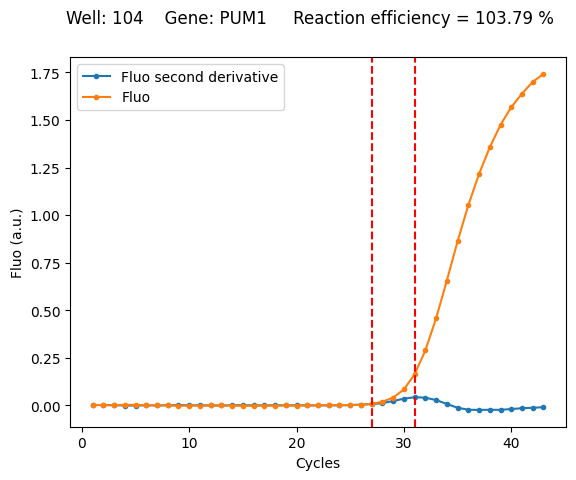

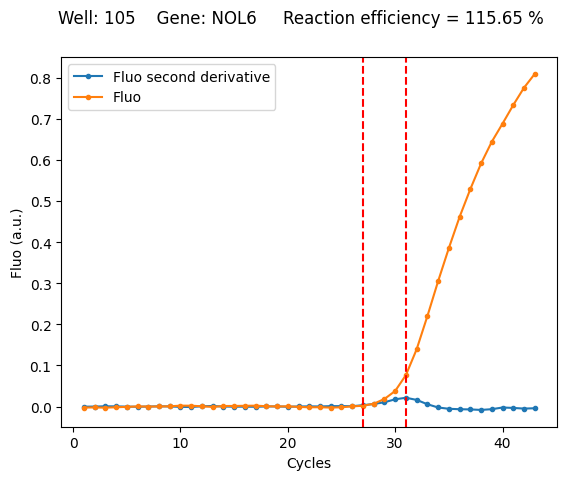

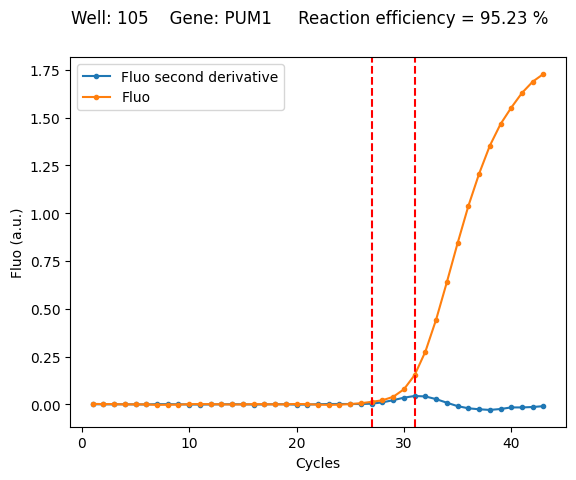

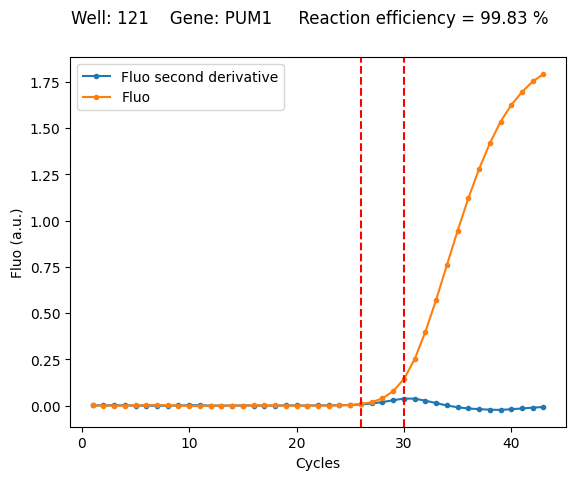

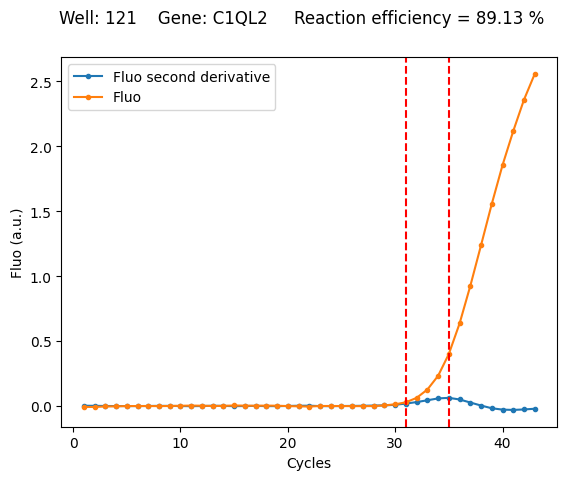

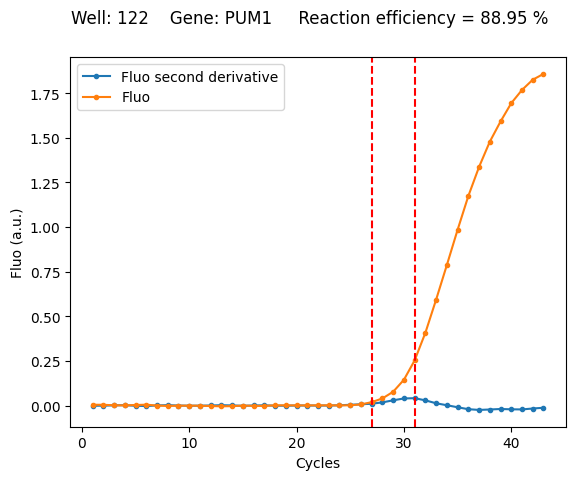

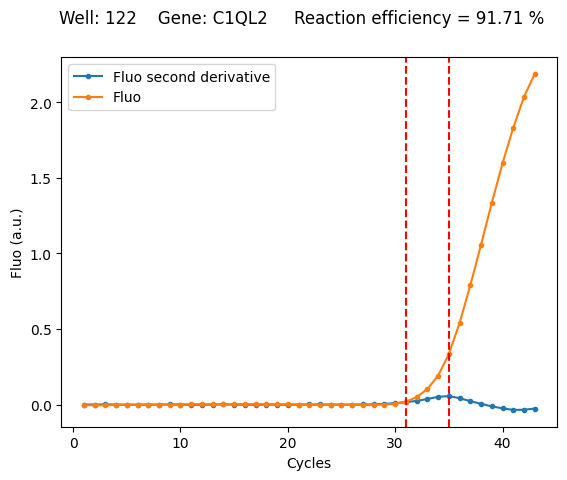

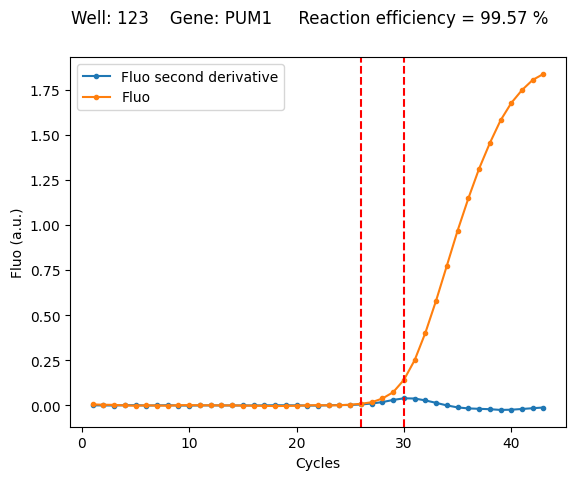

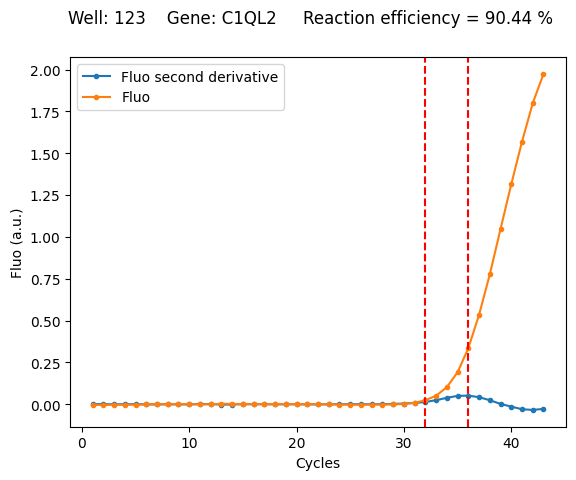

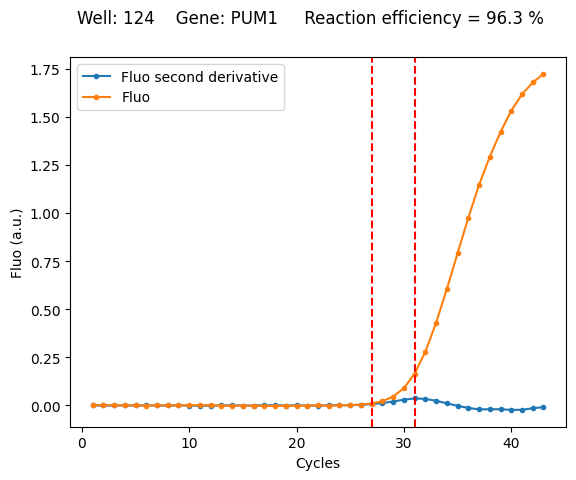

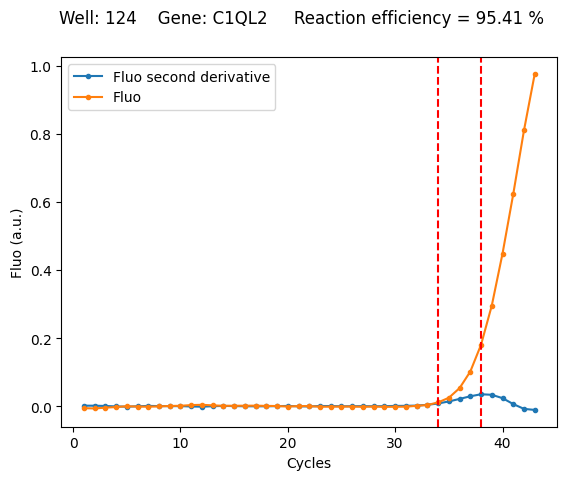

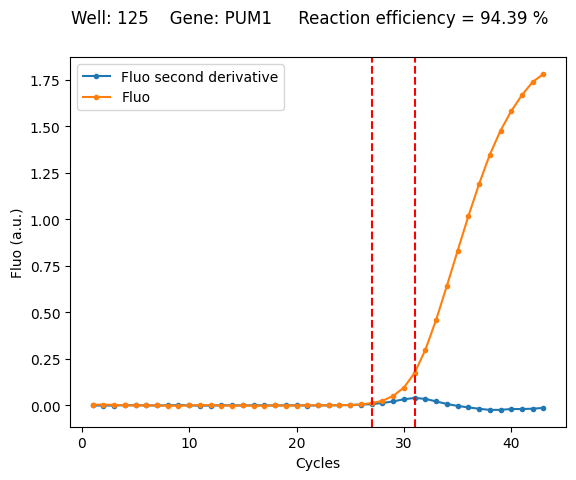

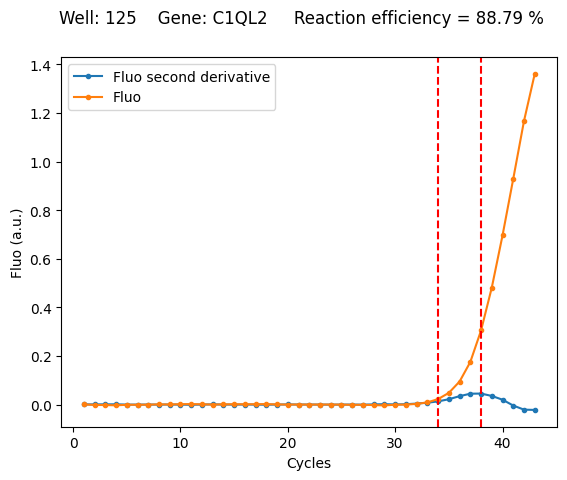

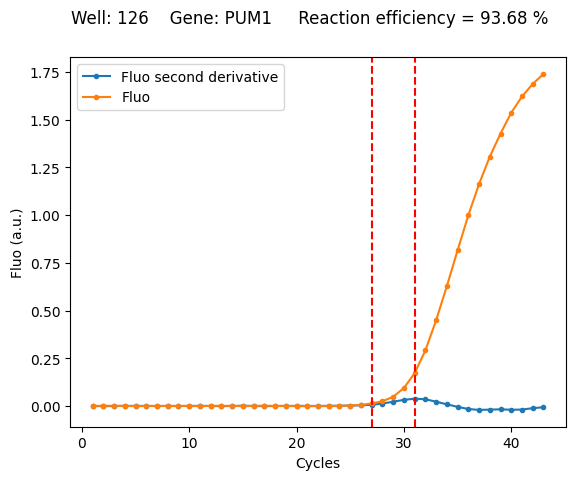

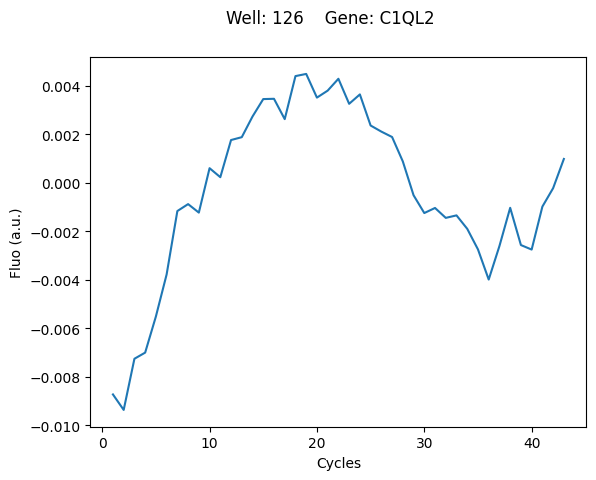

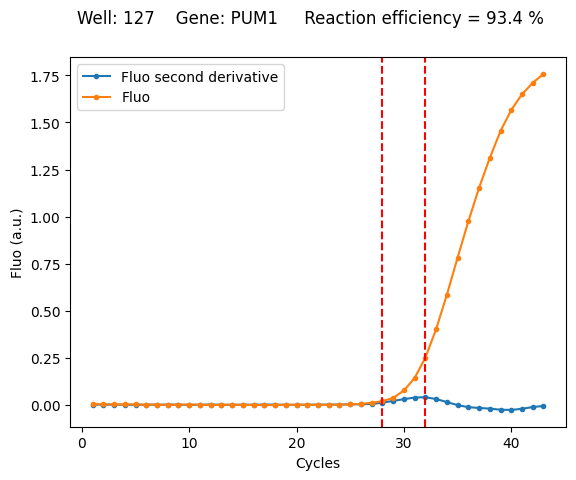

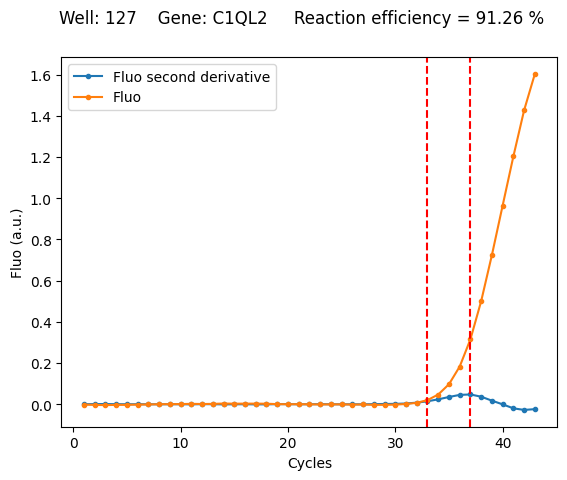

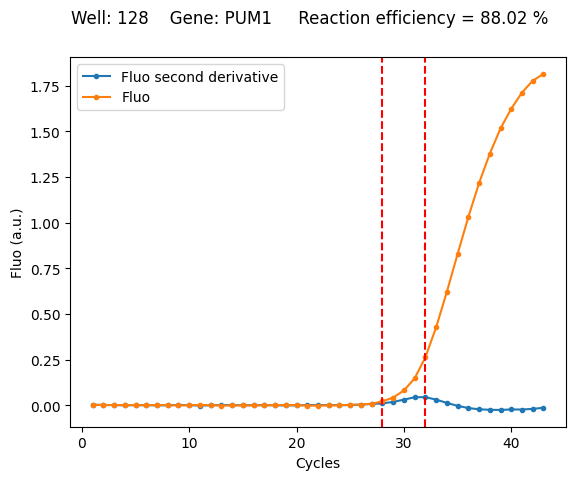

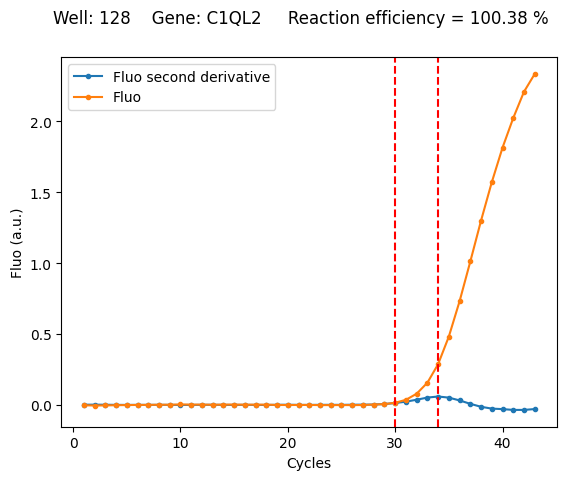

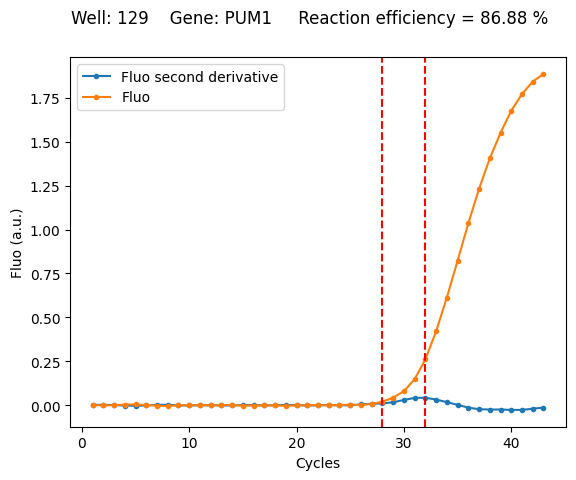

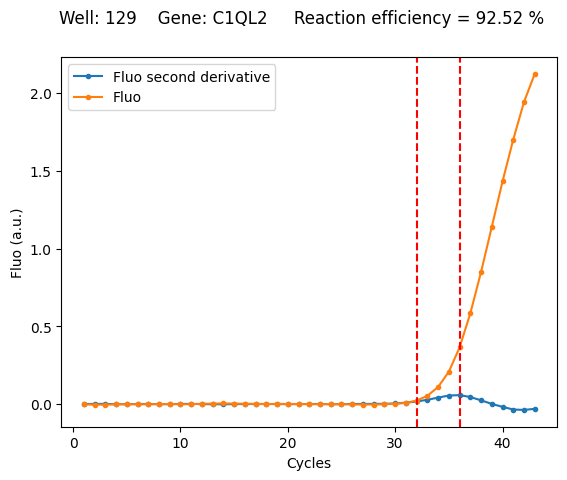

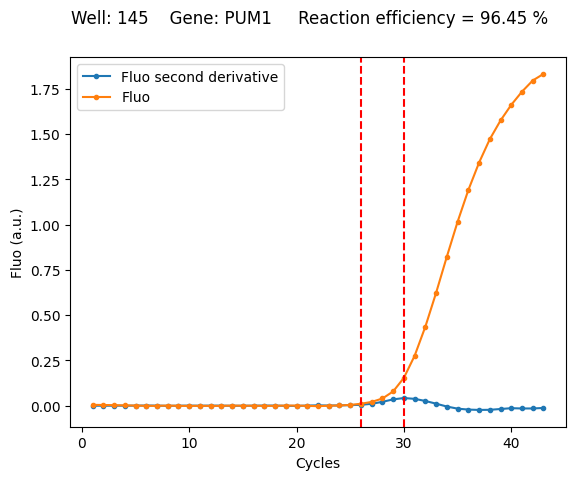

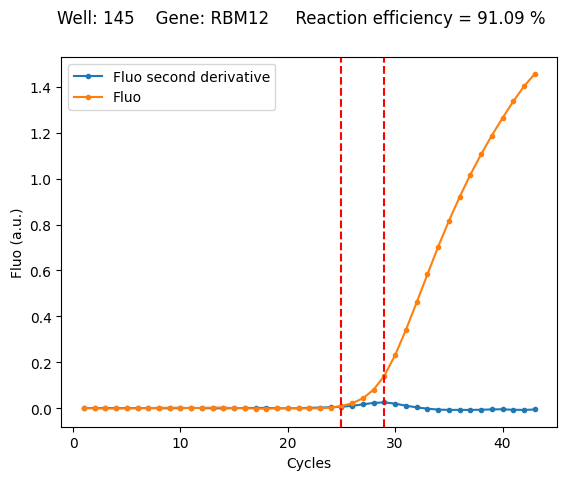

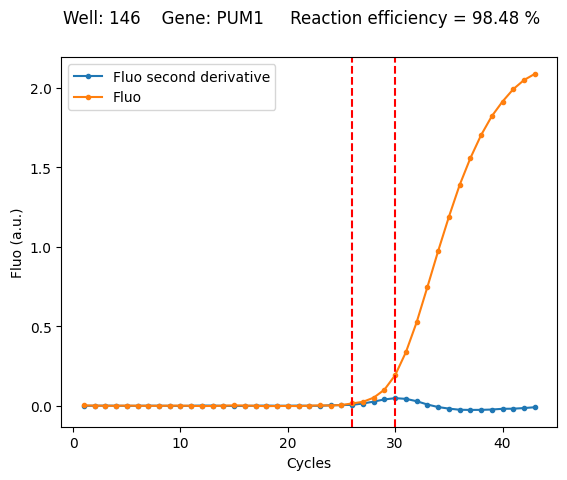

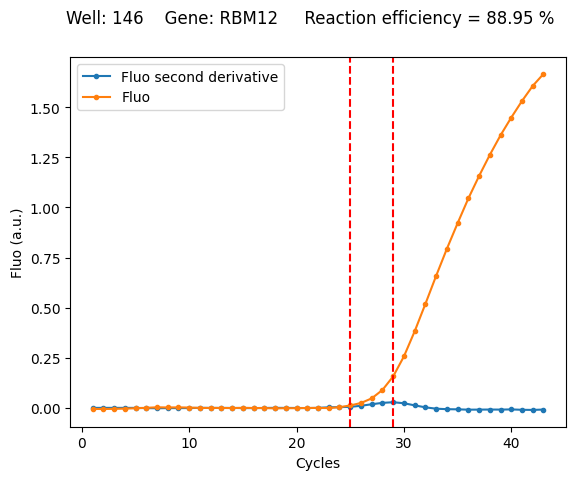

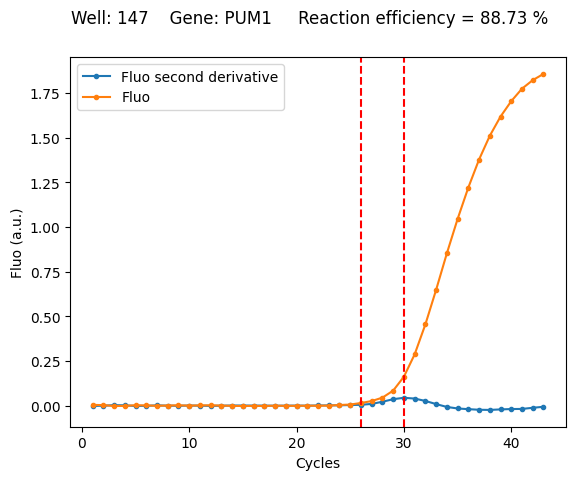

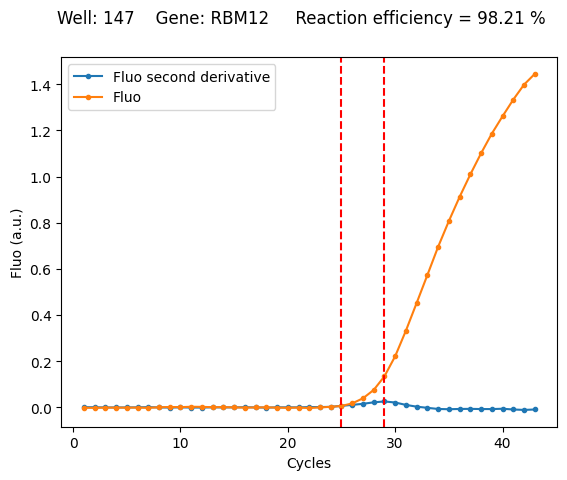

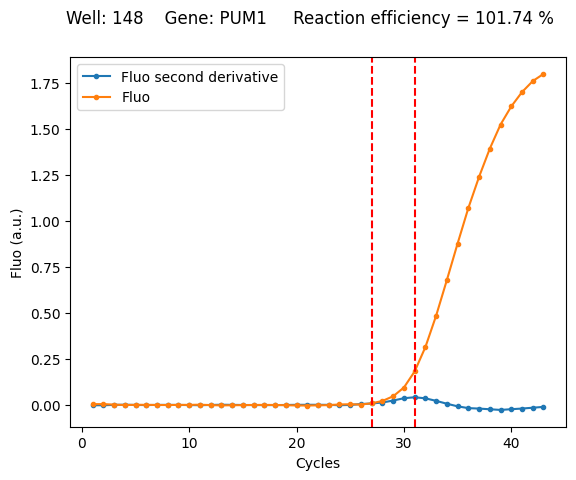

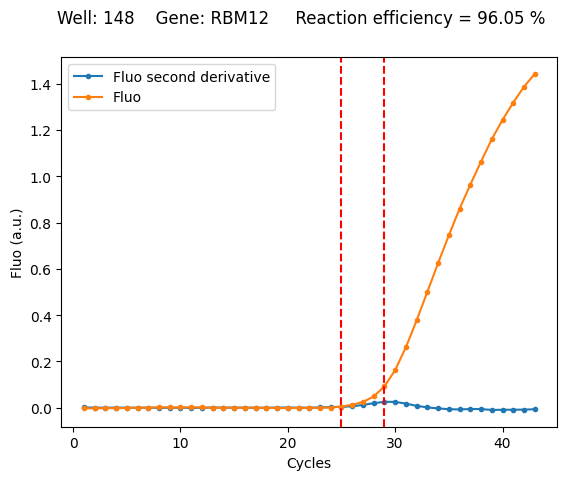

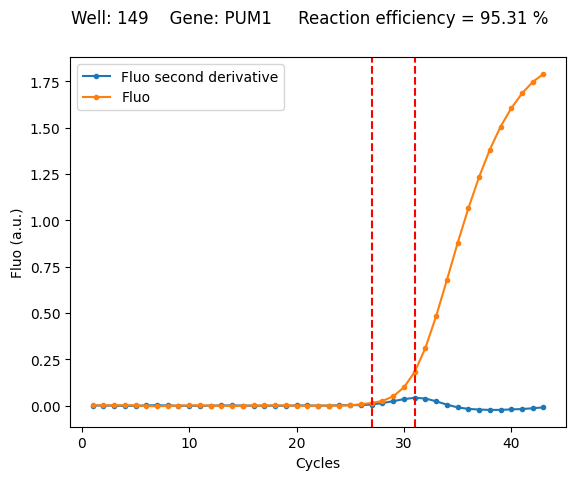

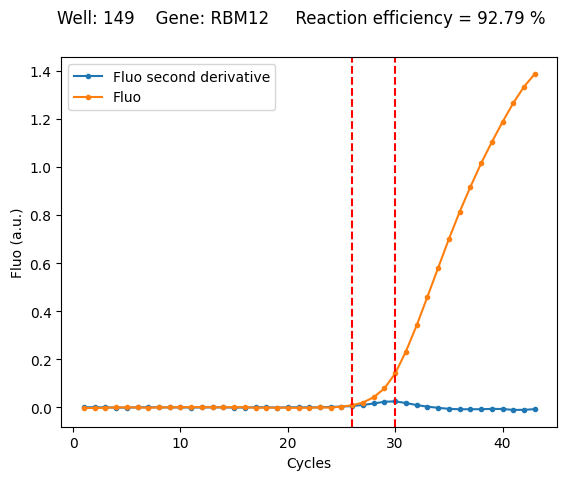

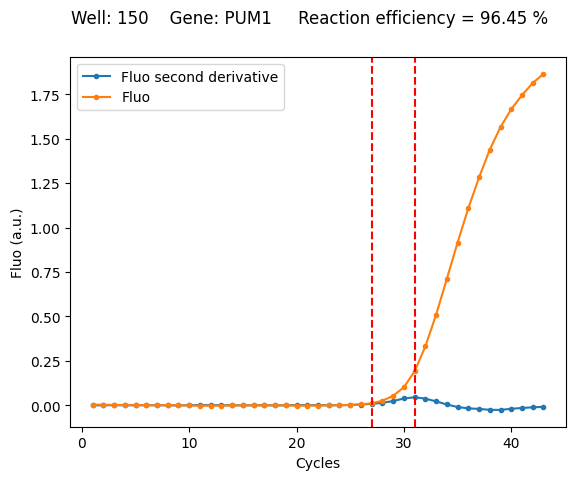

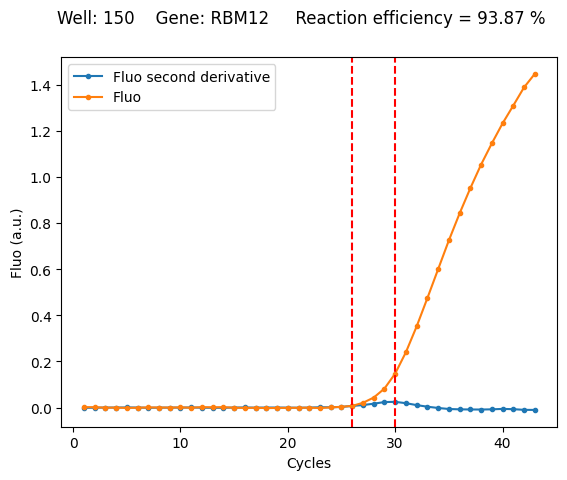

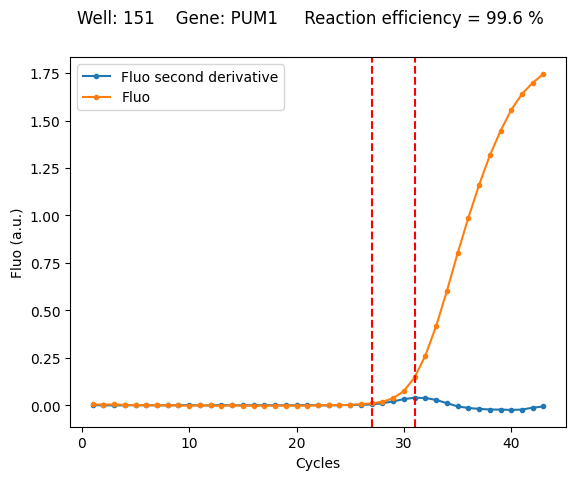

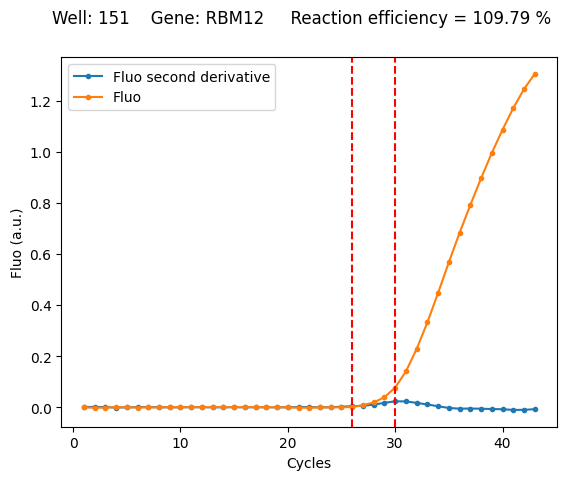

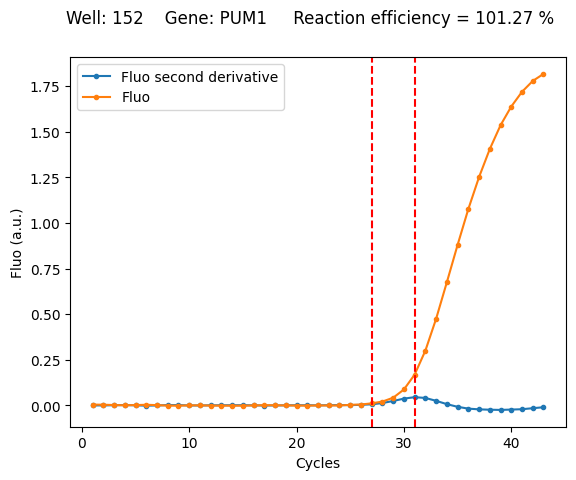

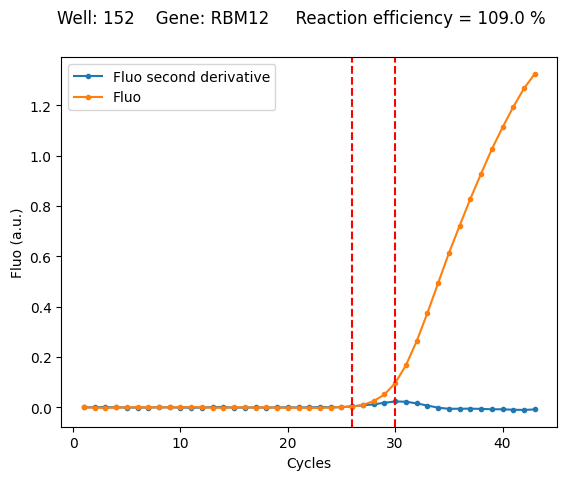

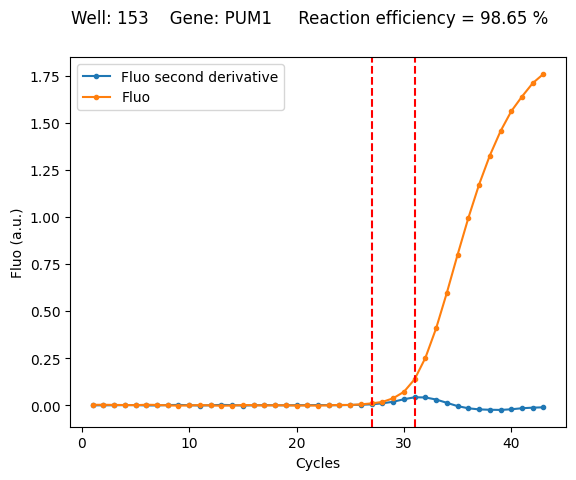

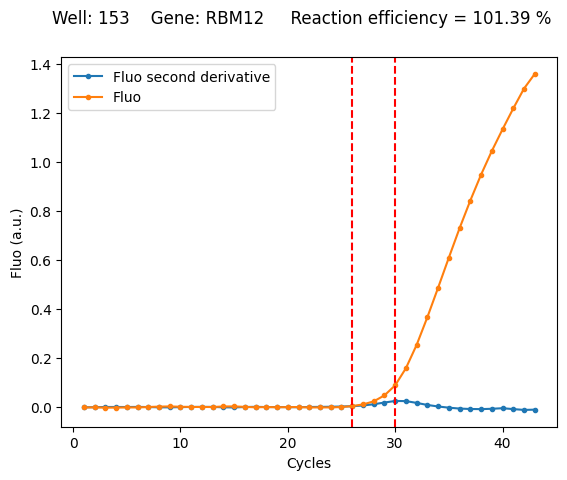

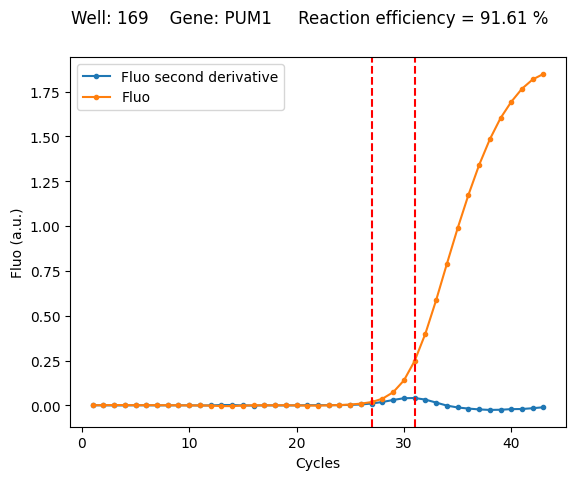

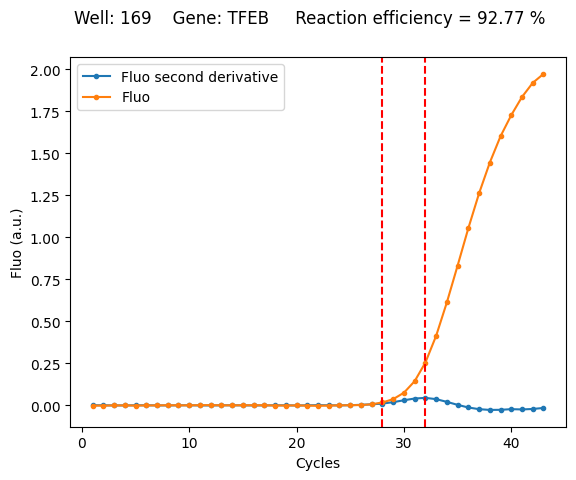

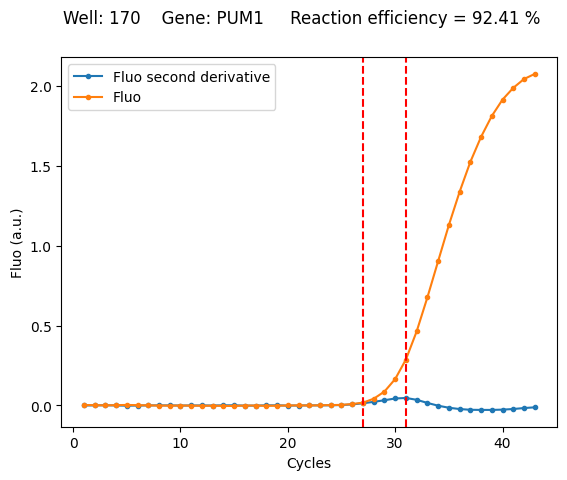

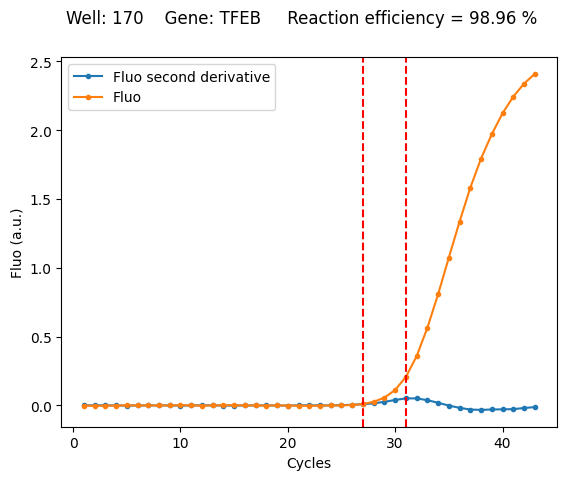

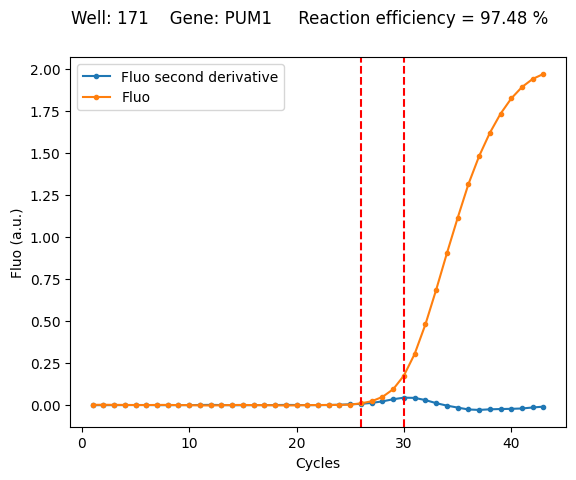

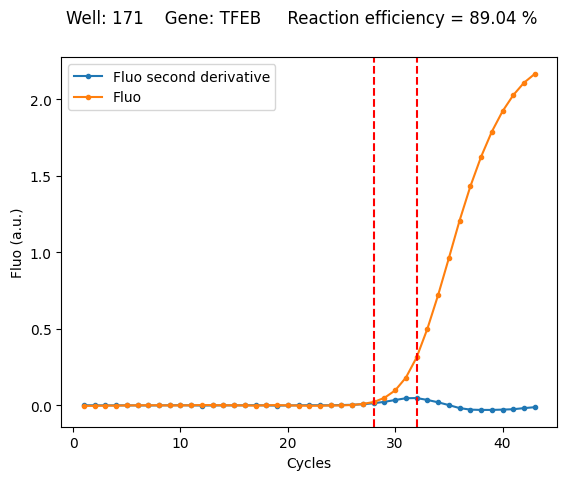

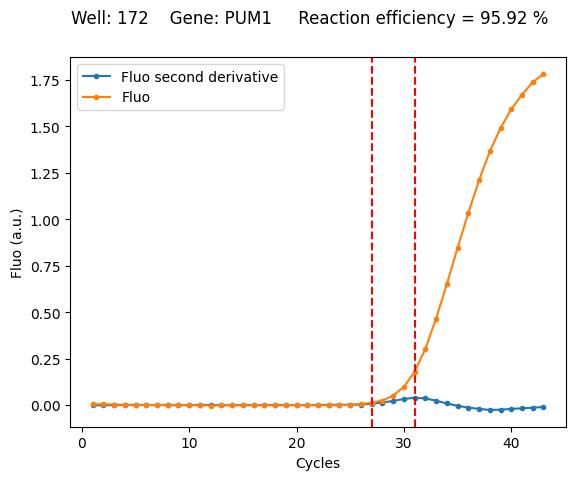

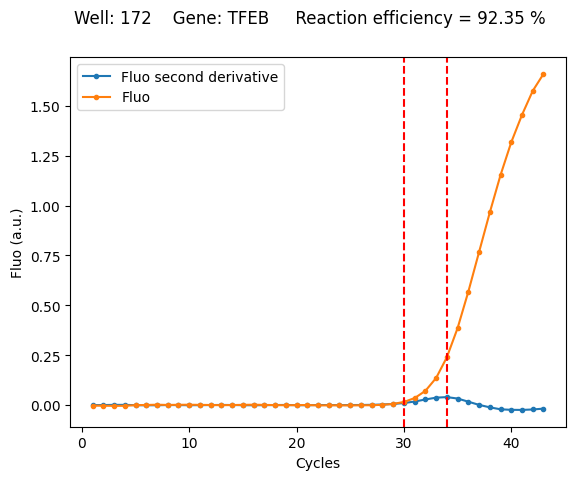

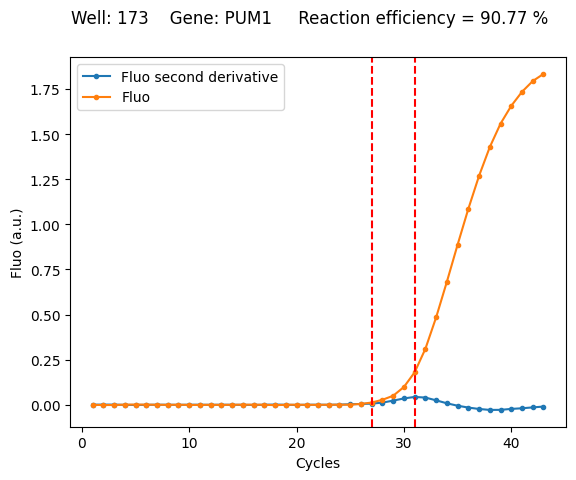

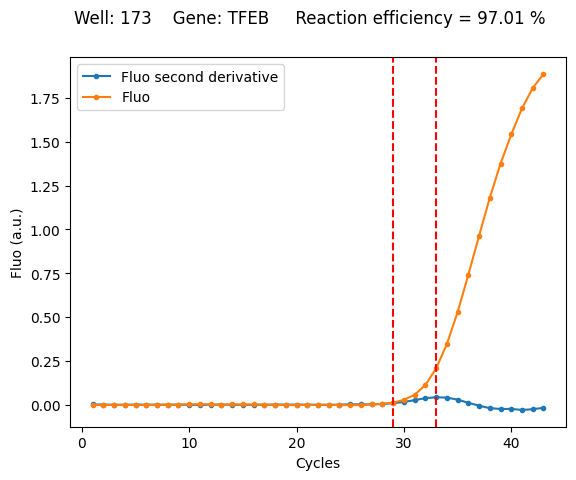

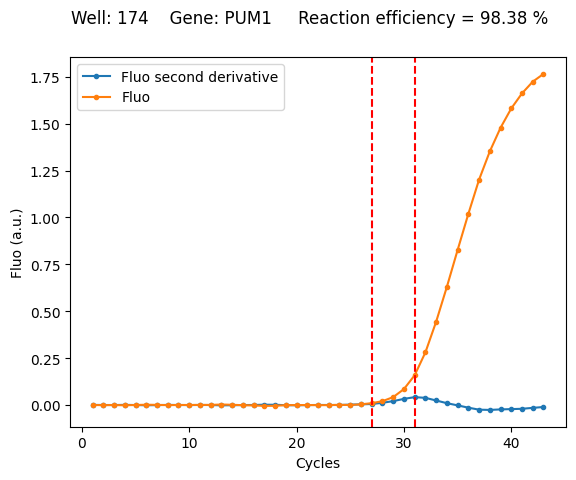

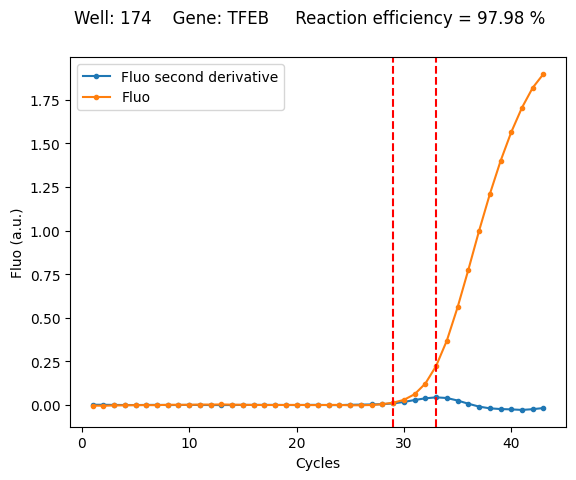

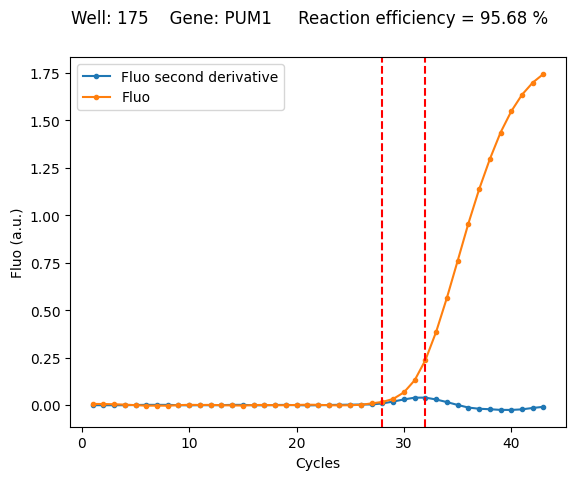

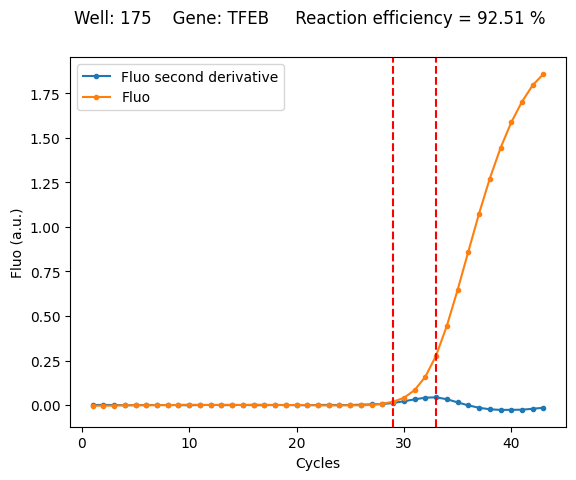

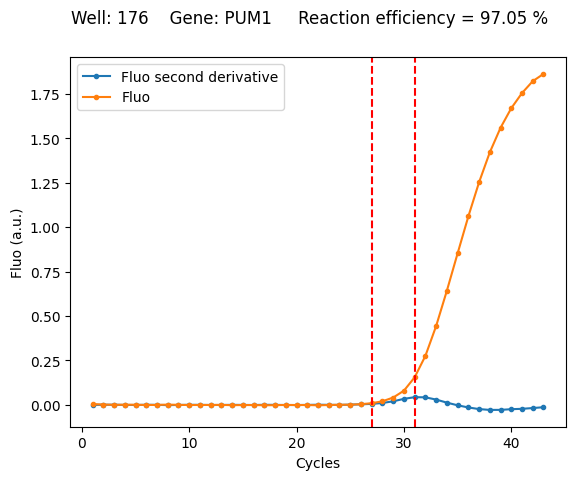

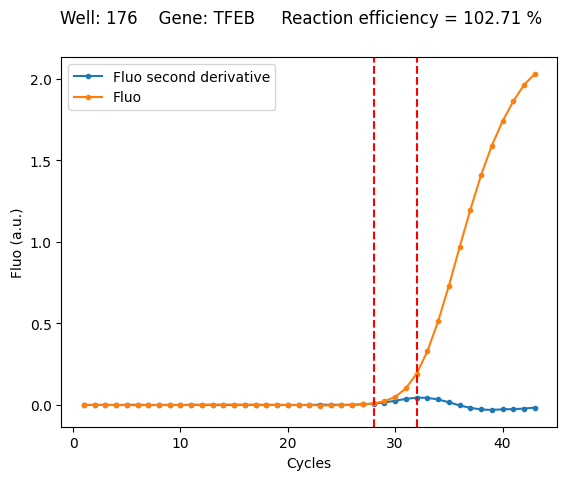

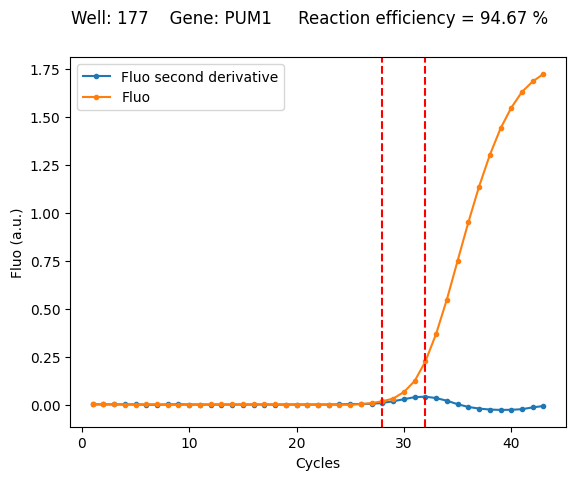

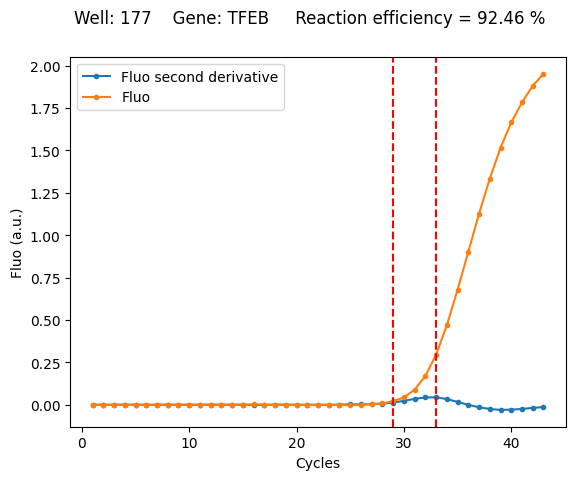

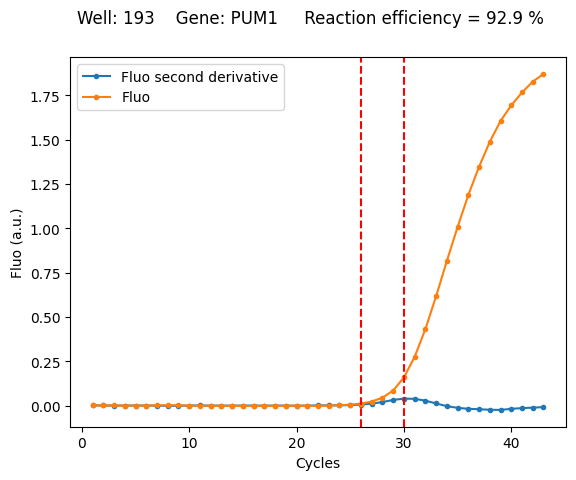

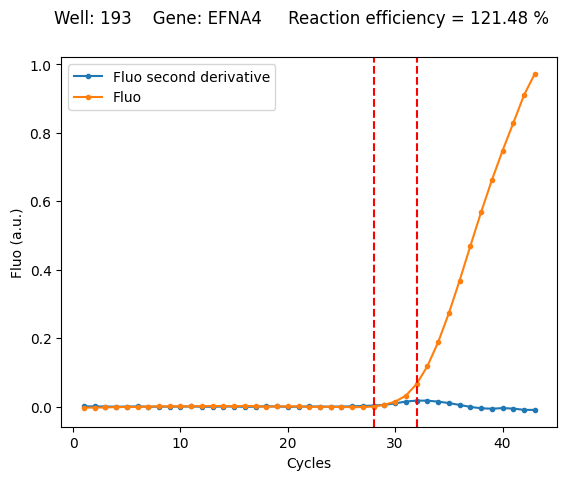

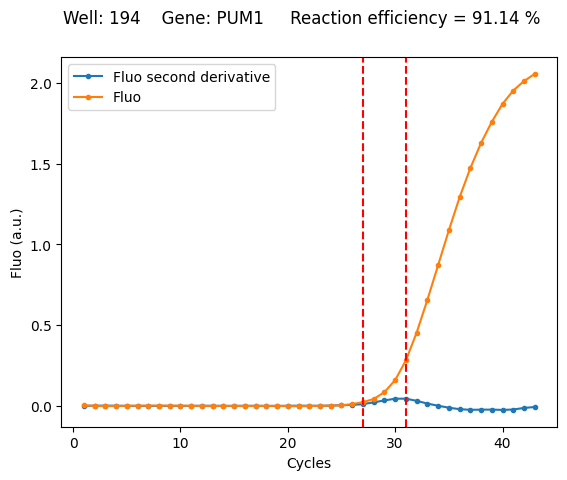

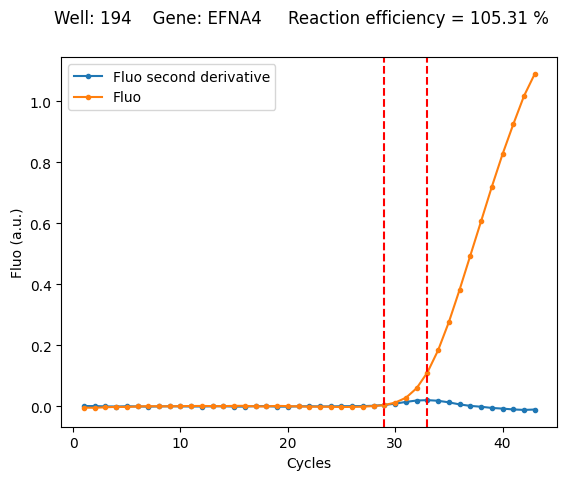

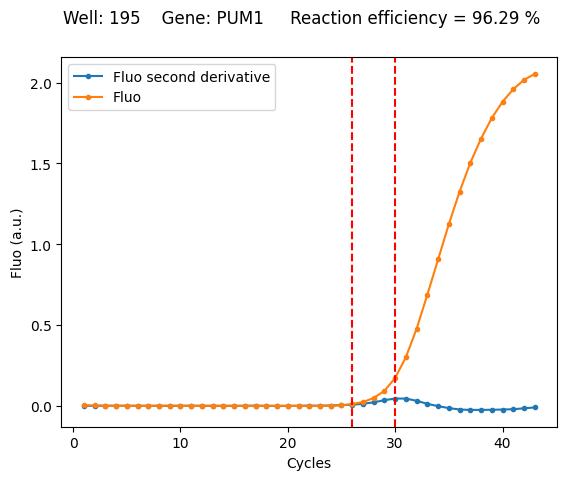

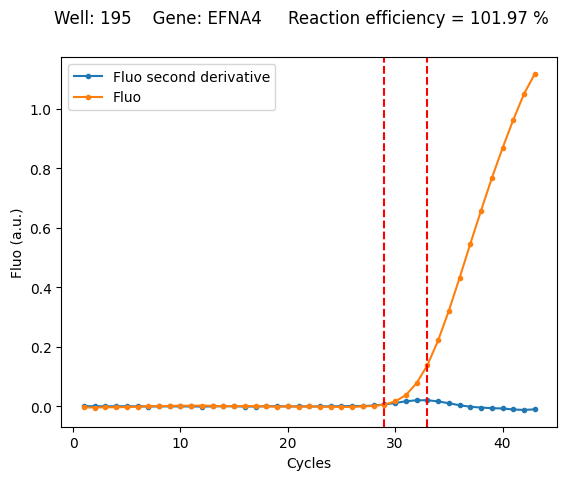

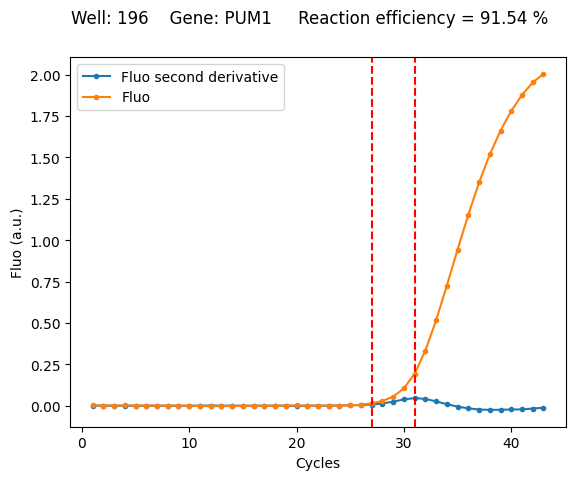

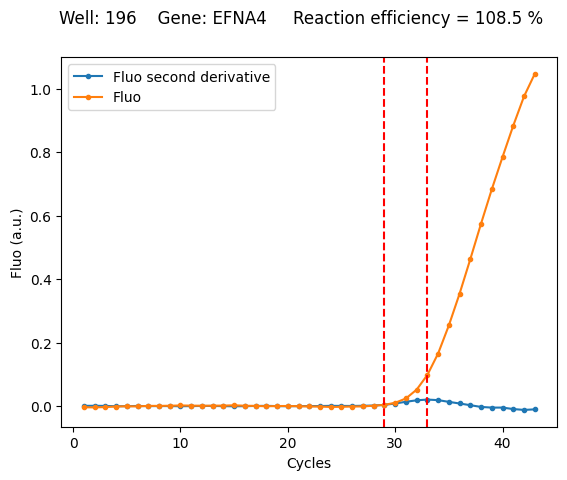

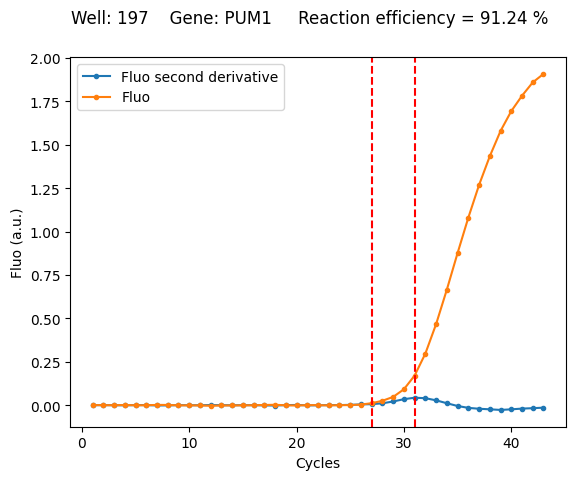

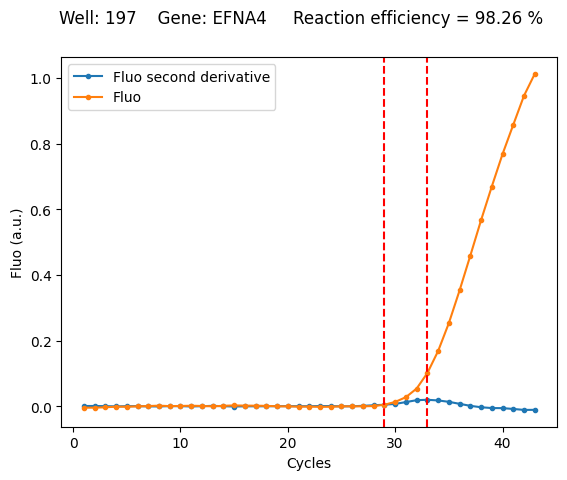

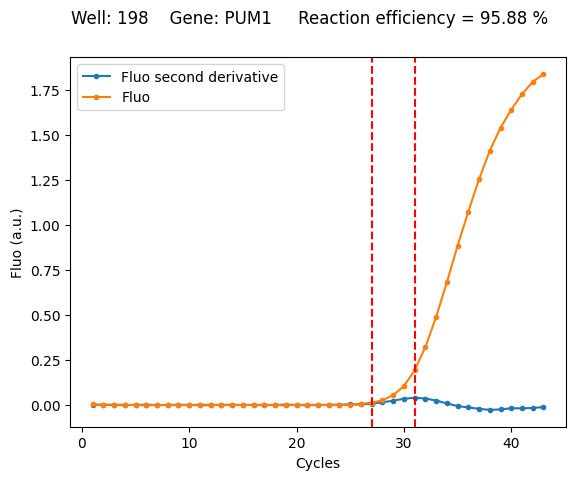

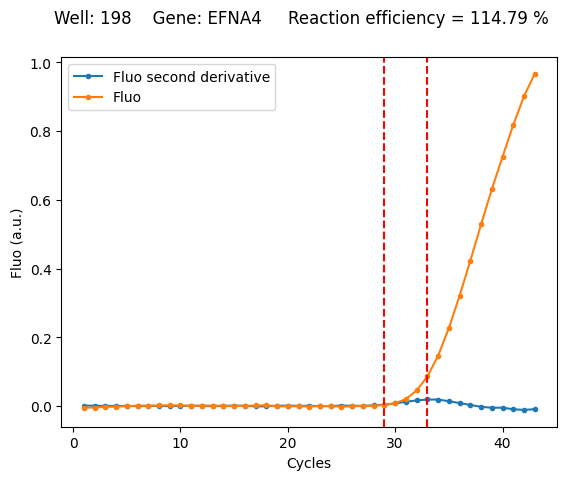

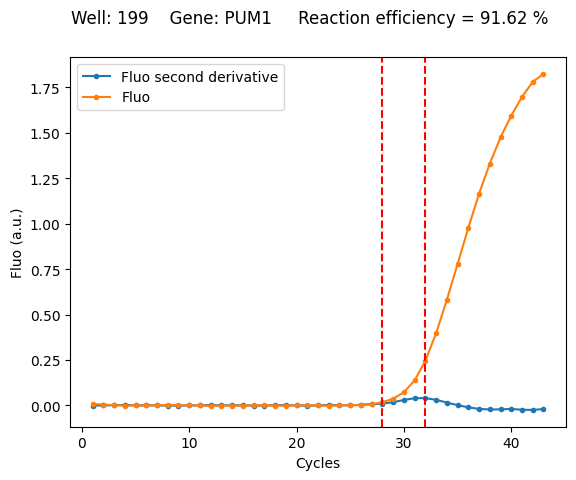

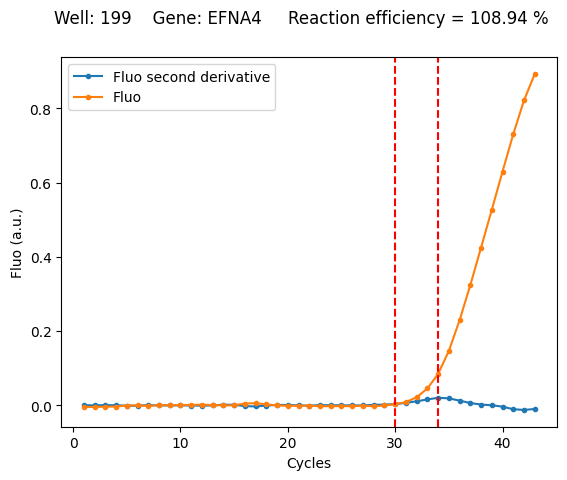

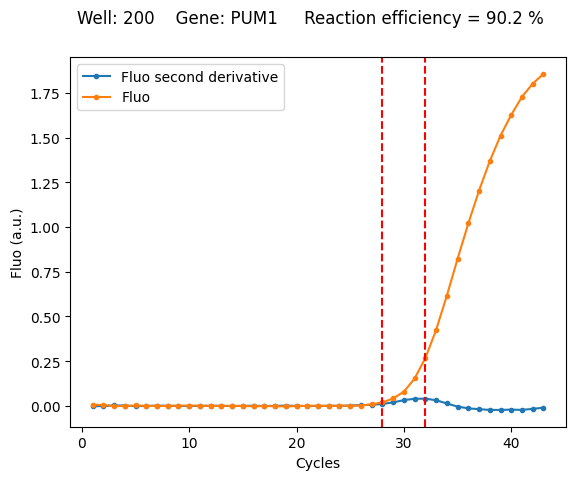

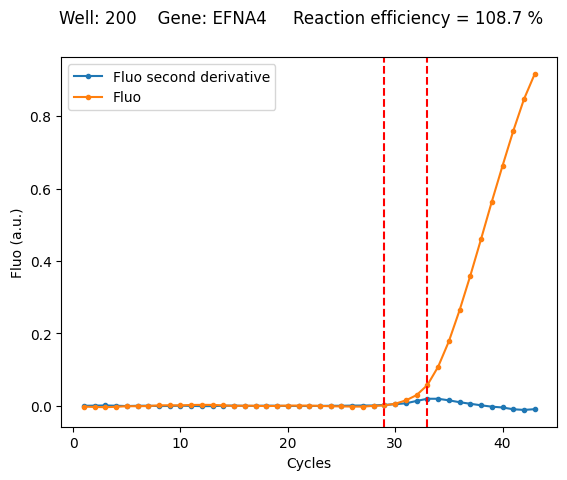

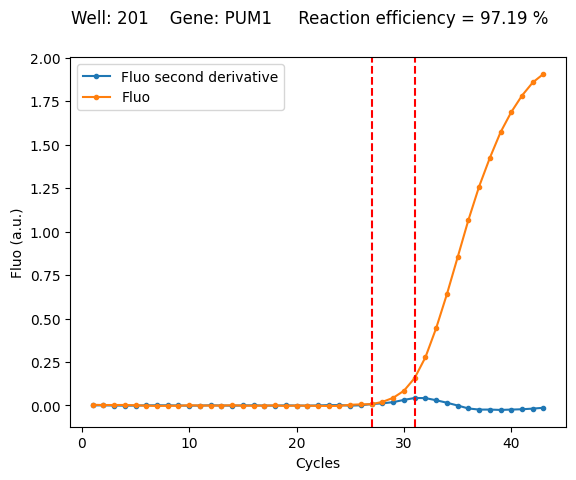

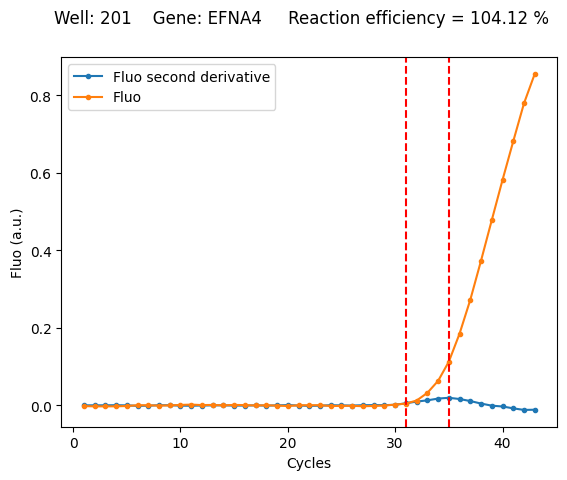

In [38]:
efficenciency_list = [] #list to stock the reaction efficiency of each sample
coordinate = [] #list to stock the coordinate of each sample (well + gene) to merge it with the results dataframe after
coordinate_outliers = [] #list to stock the coordinate of the sample with non-finite values or not enough correct points to merge it with the results dataframe after

for i in range(len(df_ampli)//nb_cycl): 
    plt.figure()
    graph = df_ampli.loc[i*nb_cycl: i*nb_cycl+(nb_cycl-1), ['cycle', 'Delta Rn']] #-1 because the line has one more notch than the cycle (like at zero)
    gradient2 = np.gradient(np.gradient(graph['Delta Rn'], graph['cycle'])) #second derivative
    index_SDM = np.argmax(gradient2)
    cycle_SDM = graph.iloc[index_SDM]['cycle'] #identification of the cycle at which the second derivative is maximum
    transfo_log = graph.iloc[index_SDM-3 : index_SDM+1][['cycle', 'Delta Rn']] # +1 because the index is not included with iloc
    transfo_log[['Delta Rn', 'cycle']] = transfo_log [['Delta Rn', 'cycle']].apply(pd.to_numeric, errors='coerce')
    transfo_log['log2'] = np.log2(transfo_log['Delta Rn']) #transformation of the fluorescence values in log2 to be able to apply a linear regression and calculate the efficiency of the reaction

#check if there are enough correct points and if the value are finite (e.g. if the value of fluorescence is negative, the log2 will be non-finite) 
    if len(transfo_log) < 2 or not np.isfinite(transfo_log['log2']).all(): 
        print(f"⚠️ Not enough correct points or non-finite values for={df_ampli.loc[i*nb_cycl, 'well']}, gene={df_ampli.loc[i*nb_cycl, 'target name']}")
        plt.plot(graph['cycle'], graph['Delta Rn']) #plot the fluorescence curve to check by eye
        plt.xlabel('Cycles')
        plt.ylabel('Fluo (a.u.)')
        plt.suptitle(f"Well: {df_ampli.loc[i*nb_cycl, 'well']}    Gene: {df_ampli.loc[i*nb_cycl, 'target name']}")
        efficiency = np.nan
        efficenciency_list.append(efficiency) 
        gene = str(df_ampli.loc[i*nb_cycl, 'target name'])
        well = str(df_ampli.loc[i*nb_cycl, 'well']) 
        coordinate.append( well + gene)
        coordinate_outliers.append(well + gene)
        continue
    
    efficiency = np.polyfit(transfo_log['cycle'], transfo_log['log2'], 1) #linear regression to calculate the slope 
    efficiency = round(efficiency[0] * 100, 2) #calculation of the efficiency in percent
    efficenciency_list.append(efficiency) #feed the list of efficiency with the value of the current sample
    
    well = str(df_ampli.loc[i*nb_cycl, 'well']) 
    gene = str(df_ampli.loc[i*nb_cycl, 'target name'])
    coordinate.append( well + gene)  #feed the coordinate list with the value of the current sample 
        
    plt.plot(graph['cycle'], gradient2, linestyle='-', marker='.', label='Fluo second derivative') #plot the second derivative
    plt.plot(graph['cycle'], graph['Delta Rn'], linestyle='-', marker='.', label='Fluo') #plot the fluorescence curve
    plt.axvline(x=cycle_SDM , color='red', linestyle='--')
    plt.axvline(x=cycle_SDM-4, color='red', linestyle='--') #red lines to visualize the window of 4 cycles used for the linear regression to calculate the efficiency
    plt.xlabel('Cycles')
    plt.ylabel('Fluo (a.u.)')
    plt.suptitle(f"Well: {well}    Gene: {gene}     Reaction efficiency = {efficiency} %")
    plt.legend()

efficenciency_final = pd.DataFrame({"efficicence" : efficenciency_list, "coordinate" : coordinate})  
#effi_pum1 = efficenciency_final.loc[efficenciency_final['coordinate'].str.contains('PUM1'), ['efficicence']] #c'est pour selectionner toutes case efficience pourlesquelle la colonne coordinate contient PUM1
#effi_pum1
efficenciency_final

4. Merge the results dataframe obtained from the machine with the reaction efficiency data just calculated

In [39]:
df_results = results.loc[results.iloc[:, 3].notna(), :]
df_results = df_results.reset_index(drop = True)
df_results.columns = df_results.iloc[0, :]
df_results = df_results.iloc[1:, :]
df_results['coordinate'] = df_results.loc[:, 'Well'].astype(str) + df_results.loc[:, 'Target Name'].astype(str) #Create a column with the coordinate (well + gene) to be able to merge the results dataframe with the efficiency dataframe
#df_results['coordinate'] = df_results.iloc[:, 0].astype(str) + df_results.iloc[:, 4].astype(str) 
df_results = df_results.merge(efficenciency_final, on='coordinate') #Merge 
df_results



,Well,Well Position,Omit,Sample Name,Target Name,Task,Reporter,Quencher,Quantity,Quantity Mean,...,Custom2,Custom3,Custom4,Custom5,Custom6,HIGHSD,NOAMP,EXPFAIL,coordinate,efficicence
0,1,A1,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,1PUM1,94.86
1,1,A1,False,FLS_LOW OA10,SUN1,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,1SUN1,83.07
2,2,A2,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,2PUM1,100.71
3,2,A2,False,FLS_LOW OA10,SUN1,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,2SUN1,89.21
4,3,A3,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,3PUM1,100.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,199,I7,False,FLS_LATE OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,199PUM1,91.62
158,200,I8,False,FLS_LATE OA10,EFNA4,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,200EFNA4,108.70
159,200,I8,False,FLS_LATE OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,200PUM1,90.20
160,201,I9,False,FLS_LATE OA10,EFNA4,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,N,N,N,201EFNA4,104.12


5. Calculation and plotting of the efficiency-corrected target quantity (N₀), normalized to the housekeeping gene corrected quantity.

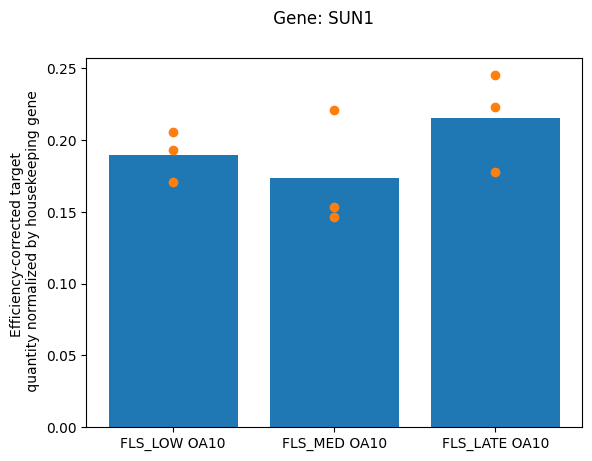

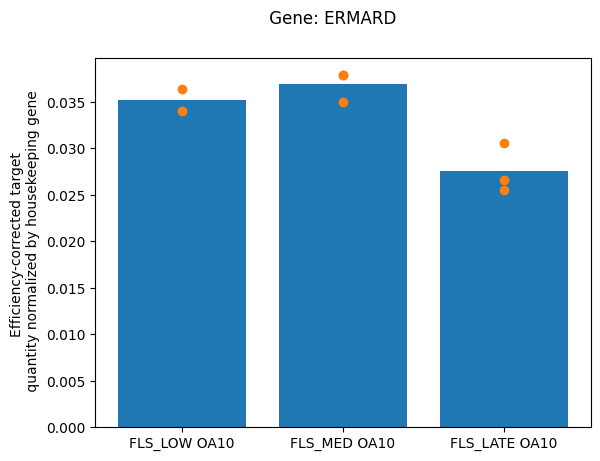

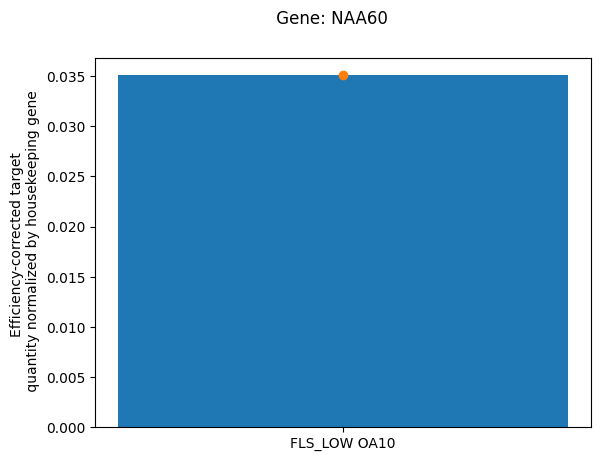

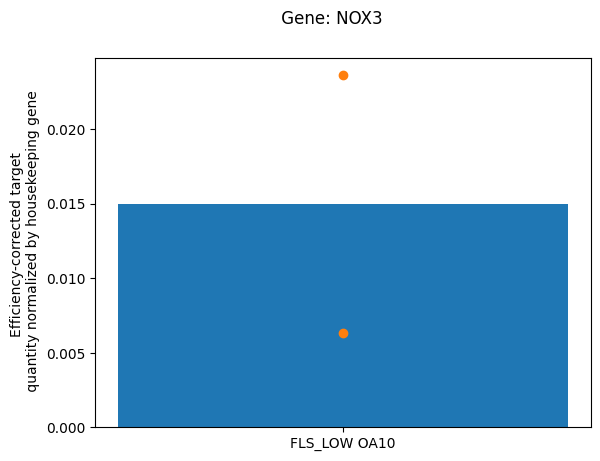

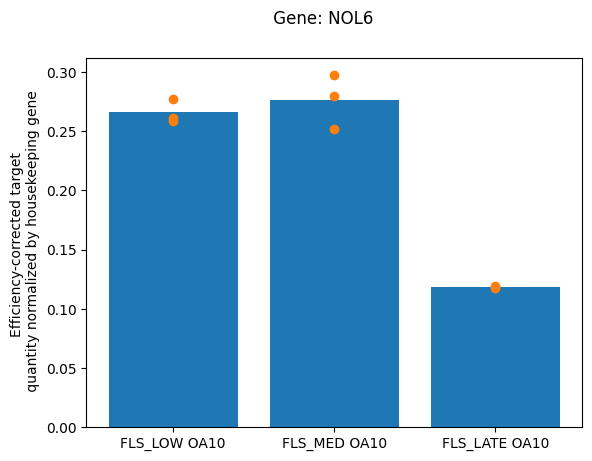

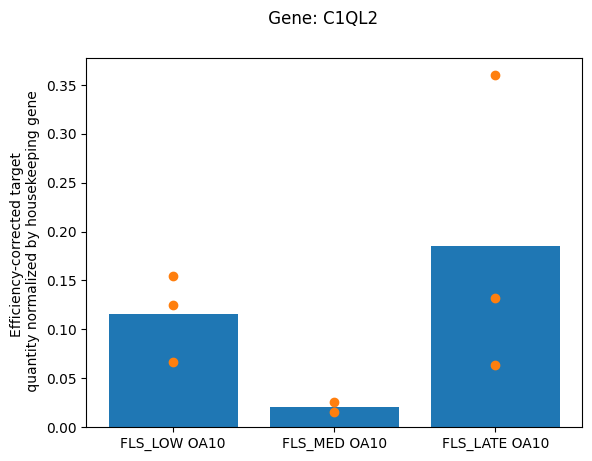

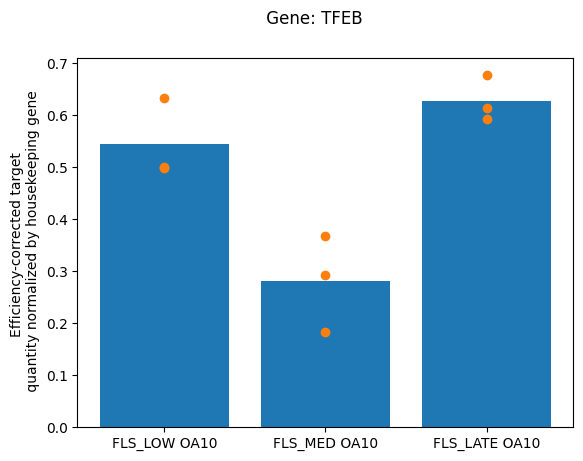

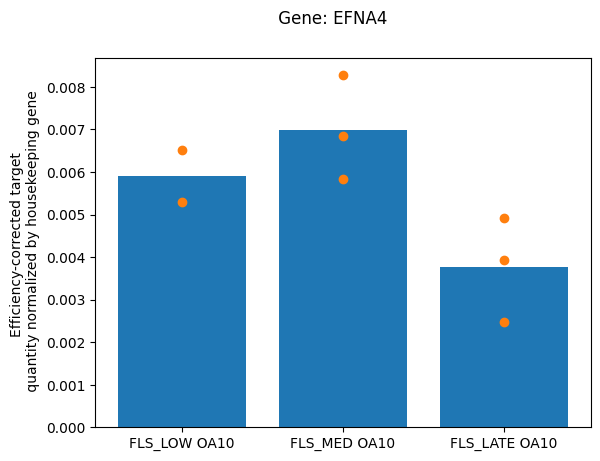

In [40]:

outliers_total = [] #list to stock outliers for which the reaction efficiency is not in the range defined by the user or for which there were not enough correct points or non-finite values to calculate the efficiency.
ratios_all = []


for i in genes_list: 
    well_names = df_results.loc[df_results['Target Name']== i, :] 
    cdt_of_interest = df_results.loc[df_results['Well Position'].isin (well_names['Well Position']), :] #sub-table with our GOI and the reference gene, we will do the calculations and the graph with this table
    outliers = cdt_of_interest.loc[(cdt_of_interest['efficicence'] < efficience_min) | (cdt_of_interest['efficicence'] > efficience_max), 'Well Position'] #identification of outlier for which the reaction efficency is out of the range defined by the user
    outliers_for_table = cdt_of_interest.loc[(cdt_of_interest['efficicence'] < efficience_min) | (cdt_of_interest['efficicence'] > efficience_max), ['Well Position','Target Name' , 'Sample Name', 'coordinate']] 
    outliers_total.append(outliers_for_table)   #feed the list of outliers with the value of the current sample
    cdt_of_interest = cdt_of_interest.loc[~cdt_of_interest['Well Position'].isin(outliers), :] # selection of lines without outliers
    cdt_of_interest['real efficiency'] = 2**(cdt_of_interest['efficicence']/100) 
    goi_mean_efficiency = cdt_of_interest.loc[cdt_of_interest['Target Name'] == i, 'real efficiency'].mean() #mean efficiency for the GOI (it is essential to calculate this mean to compare the expression of the GOI between the different sample conditions)
    ref_mean_efficiency = cdt_of_interest.loc[cdt_of_interest['Target Name'] == reference_gene, 'real efficiency'].mean() #same for the reference gene (housekeeping gene)
    cdt_of_interest.loc[cdt_of_interest['Target Name'] == i, 'mean efficiency'] = goi_mean_efficiency 
    cdt_of_interest.loc[cdt_of_interest['Target Name'] == reference_gene, 'mean efficiency'] = ref_mean_efficiency 
    cdt_of_interest['CT'] = pd.to_numeric(cdt_of_interest['CT'], errors='coerce')
    cdt_of_interest['N0'] = cdt_of_interest['Ct Threshold']*cdt_of_interest['mean efficiency']**(-(cdt_of_interest['CT'])) #N0 calculation 
    pivot = cdt_of_interest.pivot(index = 'Well Position', columns = 'Target Name', values = 'N0') 
    pivot['ratio_target_ref'] = pivot[i]/pivot[reference_gene] #normalization of the quantity of the GOI by the quantity of the reference gene to be able to compare the expression of the GOI between the different sample conditions
    ratio = pivot['ratio_target_ref'] 
    cdt_of_interest = cdt_of_interest.merge(ratio, on = 'Well Position') 
    ratios_all.append(cdt_of_interest[['coordinate','real efficiency', 'N0', 'ratio_target_ref']].drop_duplicates()) #feed the list of ratio with the value of the current sample, we drop duplicates to avoid having twice the same line for the same sample because we have one line for the GOI and one line for the reference gene
    means = cdt_of_interest.groupby('Sample Name', sort = False)['ratio_target_ref'].mean() #calculate the mean ratio for each sample for the barplot
    plt.bar(means.index, means.values)
    plt.ylabel('Efficiency-corrected target \n quantity normalized by housekeeping gene')
    plt.suptitle(f" Gene: {i}  ")
    plt.scatter(cdt_of_interest.loc[cdt_of_interest['Target Name'] == i, 'Sample Name'], 
    cdt_of_interest.loc[cdt_of_interest['Target Name'] == i, 'ratio_target_ref'])
    plt.show()
outliers_total.append(df_results.loc[df_results['coordinate'].isin(coordinate_outliers),['Well Position', 'Target Name', 'Sample Name', 'coordinate']])
outliers_total = pd.concat(outliers_total)
ratios_all = pd.concat(ratios_all)
speadsheet_final = df_results.merge(
    ratios_all,
    on='coordinate',
    how='left'
)
filename = datetime.now().strftime("qpcr_results_%Y%d%m_%H%M.xlsx") #name of the output file with the date and time to avoid overwriting previous results
with pd.ExcelWriter(filename) as writer:
    speadsheet_final.to_excel(writer, sheet_name="results", index=False)
    outliers_total.to_excel(writer, sheet_name="outliers", index=False)


In [41]:
speadsheet_final

,Well,Well Position,Omit,Sample Name,Target Name,Task,Reporter,Quencher,Quantity,Quantity Mean,...,Custom5,Custom6,HIGHSD,NOAMP,EXPFAIL,coordinate,efficicence,real efficiency,N0,ratio_target_ref
0,1,A1,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,1PUM1,94.86,1.929999,0.0,0.205555
1,1,A1,False,FLS_LOW OA10,SUN1,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,1SUN1,83.07,1.778548,0.0,0.205555
2,2,A2,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,2PUM1,100.71,2.009867,0.0,0.171021
3,2,A2,False,FLS_LOW OA10,SUN1,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,2SUN1,89.21,1.855876,0.0,0.171021
4,3,A3,False,FLS_LOW OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,3PUM1,100.63,2.008753,0.0,0.192813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,199,I7,False,FLS_LATE OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,199PUM1,91.62,1.887138,0.0,0.003926
158,200,I8,False,FLS_LATE OA10,EFNA4,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,200EFNA4,108.70,2.124318,0.0,0.004917
159,200,I8,False,FLS_LATE OA10,PUM1,UNKNOWN,VIC,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,200PUM1,90.20,1.868655,0.0,0.004917
160,201,I9,False,FLS_LATE OA10,EFNA4,UNKNOWN,FAM,NFQ-MGB,NaN,NaN,...,NaN,NaN,N,N,N,201EFNA4,104.12,2.057939,0.0,0.002463
